## Imports

In [246]:
import sys
import os
import yaml
import pyaml
import shutil
import numpy as np
import pandas as pd
import polars as pl
import json
import csv
import matplotlib
import matplotlib.pyplot as plt
import random

from pathlib import Path
from collections import Counter

# Pheval phenopacket utils
from pheval.utils.phenopacket_utils import phenopacket_reader
from pheval.utils.phenopacket_utils import PhenopacketUtil

# Allows us to silence logging for pheval phenopacket reading
import logging
logging.getLogger().setLevel(logging.ERROR)

## Project information

- **High level overview**
  - This notebook details exomiser and elder disease prioritization algorithms from patient phenotype data alone.
  - Phenopacket store data 1.14 was used consisting of 5084 phenopackets after filtering.
  - Both algorithms (exomiser, and elder) were run on the set of 5084 phenopackets
  - Pheval methodolgy for post processing and results benchmarking was used (normalize disease ids to MONDO identifiers)
- **Program versions**
  - Exomiser version 14.0 with database versions 2406
  - Java 23.02 (for running exomiser)
  - Pheval version 0.7.6
  - pheval.exomiser 0.4.6.
  - download the latest version of hpo data from
     - https://github.com/obophenotype/human-phenotype-ontology/releases/download/v2026-01-08/phenotype.hpoa
     - Then we read into memory and select for the diseases that are represented in our dataset and quantify phenotype counts

## Pheval parallel processing code

In [4]:
# General multiprocessing fucntion
def divide_workload(data_list, num_proc: int=1) -> list:
    """
    Meant to divide up the elements in data_list into num_proc equal portions
    by iteratively adding each element to a basket never repeating the same basket until all baskets have an equal amount
    If num_proc == 1 then the original input list will be returned nested in a top layer list i.e. [data_list]
    """

    # Deal with our edge case at the very begginning which then is used as input into the second potential edge case
    ndata_elements = len(data_list)
    if ndata_elements < num_proc:
        num_proc = ndata_elements

    # Edge case
    if num_proc <= 1:
        return [data_list]
    else:
        baskets = [[] for i in range(0, num_proc)]
        index_count = 0
        for d in data_list:
            baskets[index_count].append(d)
            if index_count == (num_proc-1):
                index_count = 0
            else:
                index_count += 1

        #print("- Workload divided into {} portions with each portion recieving {} elements respectively...".format(num_proc, [format(len(b), ',') for b in baskets]))
        return baskets


# For batching phenopacket data from the phenopacket store in a pheval compliant way
def pheval_batchify_phenopacketstore(phenopacket_store_base_dir, output_base_dir, results_base_dir, n_batches: int=1):

    # Phenopacket store is structured as top_dir-->gene_dir-->sample(s).json
    fpaths_list = [os.path.join(phenopacket_store_base_dir, gene_dir, fname) 
                   for gene_dir in os.listdir(phenopacket_store_base_dir)
                   if os.path.isdir(os.path.join(phenopacket_store_base_dir, gene_dir))
                   for fname in os.listdir(os.path.join(phenopacket_store_base_dir, gene_dir))]

    fpaths_set = set([fpath.split('/')[-1] for fpath in fpaths_list])

    # Sanity check to make sure all sample names are uniq
    if len(fpaths_set) != len(fpaths_list):
        raise valueError("- Non unique sample names found... exiting")

    # in/out directories cannot be same
    if output_base_dir == results_base_dir:
        raise valueError("- input/output directories are not allowed to be the same")
    
    # Make our initial base dir
    if not os.path.isdir(output_base_dir):
        os.makedirs(output_base_dir, exist_ok=True)

    # Make our initial results
    if not os.path.isdir(results_base_dir):
        os.makedirs(output_base_dir, exist_ok=True)

    # Batch data
    print("- Found {} phenopackets to batch across {}-batches...".format(format(len(fpaths_set), ','), n_batches))
    batched_fpaths = divide_workload(fpaths_list, num_proc=n_batches)

    # Make new pheval ready directories for analysis downstream
    base_name = output_base_dir.split('/')[-1]
    for i,bpaths in enumerate(batched_fpaths):
        
        # For input data
        batch_dir = os.path.join(output_base_dir, "{}_batch{}".format(base_name, i))
        if not os.path.isdir(batch_dir):
            os.makedirs(batch_dir, exist_ok=True)
            os.makedirs(os.path.join(batch_dir, "phenopackets"), exist_ok=True)

            # Now fill in directory with phenopacket sample data
            for phenopacket_path in bpaths:
                new_path = os.path.join(batch_dir, "phenopackets", phenopacket_path.split("/")[-1])
                shutil.copy(phenopacket_path, new_path)

        else:
            print("- Warning, Skipping batching of initial data... Assuming it is already complete. Proceeding in attempting to create results directories...")
            #raise valueError("- {} already exists... We need new name scheme or delete the old...".format(batch_dir))

        
        # For output data
        res_dir = os.path.join(results_base_dir, "{}_batch{}".format(base_name, i))
        if not os.path.isdir(res_dir):
            os.makedirs(res_dir, exist_ok=True)
            os.makedirs(os.path.join(res_dir, "tool_input_commands"), exist_ok=True)
        
        else:
            print("- Warning, results directories already existing... Skipping")
            #raise valueError("- {} already exists... We need new name scheme or delete the old...".format(res_dir))

        print("- {} Pheval ready phenopackets made for {}... {}/{}".format(format(len(bpaths), ','), base_name, i, len(batched_fpaths)))


# Generates the parameter data for each job call in the array (.txt/tsv)
def generate_array_config(input_config):
    
    # Input variables here
    samples_dir = input_config["input_dir"]
    output_dir = input_config["output_dir"]
    runner_dir = input_config["runner_dir"]
    config_outfile = input_config["config_outfile"]

    base_name = samples_dir.split('/')[-1]
    input_dirs = [os.path.join(samples_dir, sdir) for sdir in os.listdir(samples_dir)]
    output_dirs = [os.path.join(output_dir, sdir) for sdir in os.listdir(samples_dir)]
        
    # Data structures to be converted to dataframe at the end
    config_header = ["ArrayTaskID", "InputDir", "OutputDir", "RunnerDir"]
    config = {cname:[] for cname in config_header}
    
    count = 0
    for indir,outdir in zip(input_dirs, output_dirs):
        
        # Add this file to our column
        config["ArrayTaskID"].append(count)
        config["InputDir"].append(indir)
        config["OutputDir"].append(outdir)
        config["RunnerDir"].append(runner_dir)
        count += 1

    # Write config file
    config_df = pd.DataFrame(config)
    config_df.to_csv(config_outfile, 
                     sep="\t", 
                     header=True, 
                     columns=config_header, 
                     index=False)
    return count


# Generates the job array.sh file iteself
def pheval_to_job_array(input_config):
    """
    https://blog.ronin.cloud/slurm-job-arrays/
    """
    
    # Expand input config
    samples_dir = input_config["input_dir"]
    results_dir = input_config["output_dir"]
    config_outfile = input_config["config_outfile"]
    
    # Job file specific
    job_outfile = input_config["job_outfile"]
    job_name = input_config["job_name"]

    # Generate array config file to read from
    sample_count = generate_array_config(input_config)
    
    base_command = "pheval run --input-dir $runner{}".format('\\\n')
    command_suffix =     ["--testdata-dir $indir{}".format('\\\n')]
    command_suffix.append("--runner exomiserphevalrunner{}".format('\\\n'))
    command_suffix.append("--output-dir $outdir{}".format('\\\n'))
    command_suffix.append("--version 14.0.0".format('\\\n'))
                          
    # Combine base and suffix into single command
    command = ' '.join([base_command, ' '.join(command_suffix)])

    # Last command to clean data
    # This is perhaps the most ugly yet awesome piece of code i have written 
    # The reason i HAS to be indented this way, 
    # is because it is interpreting it as real text, so any sort of spacing is taken literally
    cleanup_command = """
# Only delete if pheval finished successfully
if [[ $? -eq 0 ]]; then
    if [[ -d "{outdir}/raw_results" ]]; then
        echo "Deleting raw_results for {outdir}"
        rm -rf "{outdir}/raw_results"
    else
        echo "raw_results directory not found for {outdir}"
    fi
else
    echo "pheval run failed — NOT deleting raw_results for {outdir}"
fi
""".format(outdir="${outdir}")
    
    # Generate actual job_array script
    with open(job_outfile, 'w') as outfile:
        outfile.write('#!/bin/bash{}'.format("\n"))
        outfile.write('#SBATCH --job-name={}{}'.format(job_name, "\n"))
        outfile.write('#SBATCH --output=jobarray_%A_%a.out{}'.format("\n"))
        outfile.write('#SBATCH --error=jobarray_%A_%a.err{}'.format("\n"))
        outfile.write('#SBATCH --array=0-{}'.format(sample_count-1))
        outfile.write('\n')
        outfile.write('#SBATCH -p general{}'.format('\n'))
        outfile.write('#SBATCH -N 1{}'.format('\n'))
        outfile.write('#SBATCH --mem 64g{}'.format('\n'))
        outfile.write('#SBATCH -n 1{}'.format('\n'))
        outfile.write('#SBATCH -t 02:00:00{}'.format('\n'))
        outfile.write('\n')
        ##outfile.write('#SBATCH --mail-type=end{}'.format('\n'))
        ##outfile.write('#SBATCH --mail-user=onyen@email.unc.edu{}'.format('\n'))

        # Load modules
        outfile.write("module load java/23.0.2{}".format('\n', '\n'))
        outfile.write("module load anaconda{}".format('\n'))
        outfile.write("conda activate phevalExps{}{}".format('\n', '\n'))
        
        # Define config inputs
        outfile.write("config={}{}".format(config_outfile, '\n'))
        outfile.write("indir=$(awk -v ArrayTaskID=$SLURM_ARRAY_TASK_ID '$1==ArrayTaskID {print $2}' $config)")
        outfile.write('\n')
        outfile.write("outdir=$(awk -v ArrayTaskID=$SLURM_ARRAY_TASK_ID '$1==ArrayTaskID {print $3}' $config)")
        outfile.write('\n')
        outfile.write("runner=$(awk -v ArrayTaskID=$SLURM_ARRAY_TASK_ID '$1==ArrayTaskID {print $4}' $config)")
        outfile.write("{}{}".format('\n', '\n')) # Must do on separate line because of awk command string formatting
        
        # pheval job array commands
        outfile.write("{}{}{}".format(command, '\n', '\n'))

        # cleanup job array commands
        outfile.write("{}{}".format(cleanup_command, '\n'))


# Merge batched results (pargquet files) to new directory for benchmarking puproses
def copy_files_flat(src_dir, dst_dir, suffix="*.parquet"):
    """Recursively copy all .parquet files from src_dir to dst_dir (flat)."""
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    for path in src_dir.rglob(suffix):
        shutil.copy2(path, dst_dir / path.name)


# Merge batched results (pargquet files) to new directory for benchmarking puproses
def count_files(src_dir, suffix="*.json"):
    src_dir = Path(src_dir)
    paths = list(src_dir.rglob(suffix))
    print("- Total files found matching {} suffix = {}".format(suffix, format(len(paths), ',')))


## Pre and post processing code

In [2]:
# General imports
import os
import argparse
import copy
import multiprocessing as mp
from pathlib import Path
from typing import List, Set
from collections import Counter
import pandas as pd
import numpy as np
import polars as pl
from typing import List, Set, Optional
from pydantic import BaseModel

# Pheval phenopacket utils
from pheval.utils.phenopacket_utils import phenopacket_reader
from pheval.utils.phenopacket_utils import PhenopacketUtil

# Allows us to silence logging for pheval phenopacket reading
import logging
logging.getLogger().setLevel(logging.ERROR)

In [3]:
#########################################
### Preprocessing and data structures ###
class Patient(BaseModel):
    sample_name: str
    phenopacket_path: str
    
    # Pulled from phenopacket
    phenotype_ids: list
    phenotype_count: int
    
    disease_name: str
    disease_id: str
    
    gene_symbol: str
    gene_id: str
    
    # For sssom mappings
    disease_mapped: Optional[str] = None
    gene_mapped: Optional[str] = None
    
    # For data analysis groupings downstream
    p_group: Optional[str] = None
    d_group: Optional[str] = None
    downsample1: Optional[str] = None
    downsample2: Optional[str] = None
    downsample3: Optional[str] = None
    results: Optional[dict] = None
    

def phenopacket_paths_to_data(sample_path_dict, disease_map={}, gene_map={}):
    """
    sample_path_dict = {sample_name:path/to/phenopacket.json, ...}
    """
	
    # Return data structure and function variables
    pobjs = {}
    multi_gene, multi_dis = {}, {}
    processed, total_samples = 0, len(sample_path_dict)
	
    # Loop through all phenopackets, extract / map data and return Patient objects
    for sname, spath in sample_path_dict.items():
        
        phenopacket_util = PhenopacketUtil(phenopacket_reader(Path(spath)))
        observed_phenotypes = phenopacket_util.observed_phenotypic_features()
        phenotype_ids = [observed_phenotype.type.id for observed_phenotype in observed_phenotypes]
        phenotype_count = len(phenotype_ids)
        
        # Default is to take first term 
        # Will display how many multi terms there are at end... should be few if not none)
        dis_obj = phenopacket_util.diseases()[0]
        dis_name, dis_id = dis_obj.term.label, dis_obj.term.id
        
        gene_obj = phenopacket_util.diagnosed_genes()[0]
        gene_symbol, gene_id = gene_obj.gene_symbol, gene_obj.gene_identifier
        
        if len(phenopacket_util.diagnosed_genes()) > 1:
            multi_gene.update({sname:''})
        
        if len(phenopacket_util.diseases()) > 1:
            multi_dis.update({sname:''})
        
        #print(sname)
        #print(dis_name, dis_id)
        #print(gene_symbol, gene_id)
    
    
        # Normalize disease and gene ids by mapping to MONDO and HGNC identifiers respectively (if possible)
        normed_gene = None
        normed_disease = None
        for g in [gene_symbol, gene_id]:
            if g in gene_map:
                normed_gene = gene_map[g]
                break
    
        for d in [dis_id, dis_name]:
            if d in disease_map:
                normed_disease = disease_map[d]
                break
    
                
        pobjs.update({sname:Patient.model_validate({"sample_name":sname,
                                                    "phenopacket_path":spath,
                                                    "phenotype_ids":phenotype_ids,
                                                    "phenotype_count":phenotype_count,
                                                    "disease_name":dis_name,
                                                    "disease_id":dis_id,
                                                    "disease_mapped":normed_disease,
                                                    "gene_symbol":gene_symbol,
                                                    "gene_id":gene_id,
                                                    "gene_mapped":normed_gene})})
        
        processed += 1
        if processed % 1_000 == 0:
            print("- {}/{} phenopackets read into memory...".format(format(processed, ','),
                                                                    format(total_samples, ',')))
        
    
    print("- Multi gene diagnosis phenopackets found {}...".format(len(multi_gene)))
    print("- Multi disease diagnosis phenopackets found {}...".format(len(multi_dis)))
    print("- {} Phenopackets information read into memory...".format(format(len(pobjs), ',')))
    return pobjs



In [4]:
def read_mondo_sssom_to_mapping_table(inpath, match_pred="skos:exactMatch"):

    mapping_table = {}
    header_lines = 0
    with open(inpath, 'r') as infile:
        for line in infile:
            
            # Header info
            if line[0] == "#":
                continue
            header_lines += 1
            if header_lines == 1:
                header_info = {k:i for i,k in enumerate(line.strip('\r').strip('\n').split('\t'))}
                continue

            # Content of file to mapping table (we want to map subject ids to themselves as well)
            cols = line.strip('\r').strip('\n').split('\t')
            ##if cols[header_info["predicate_id"]] == match_pred:
            oid = header_info["object_id"]
            sid = header_info["subject_id"]
            
            mapping_table.update({cols[oid]:cols[sid]})
            mapping_table.update({cols[sid]:cols[sid]})

            mapping_table.update({cols[oid].upper():cols[sid]})
            mapping_table.update({cols[sid].upper():cols[sid]})

            if str(cols[oid]).startswith("Orpha") or str(cols[oid]).upper().startswith("ORPHA"):
                new_id = "ORPHA:{}".format(cols[oid].split(":")[1])
                mapping_table.update({new_id:cols[sid]})


    print("- {} Total terms mapping to {} subject ids...".format(format(len(mapping_table), ','), 
                                                                 format(len(set(list(mapping_table.values()))), ',')))
    return mapping_table


def read_hgnc_to_mapping_table(inpath):
    """
    Build a dictionary mapping gene identifiers to canonical HGNC IDs.

    Returns:
        tuple: (mapping dict, set of ambiguous terms)
    """
    mapping = {}
    ambiguous = set()

    with open(hgnc_path, "r") as f:
        reader = csv.DictReader(f, delimiter="\t")

        for row in reader:
            hgnc_id = row.get("hgnc_id", "").strip()
            if not hgnc_id:
                continue

            # Collect all terms for this gene
            terms = [hgnc_id]

            # Current symbol
            symbol = row.get("symbol", "").strip()
            if symbol:
                terms.append(symbol)

            # Previous symbols
            for ps in row.get("prev_symbol", "").split("|"):
                ps = ps.strip().strip('"')
                if ps:
                    terms.append(ps)

            # Alias symbols
            for alias in row.get("alias_symbol", "").split("|"):
                alias = alias.strip().strip('"')
                if alias:
                    terms.append(alias)

            # Ensembl ID
            ensembl_id = row.get("ensembl_gene_id", "").strip()
            if ensembl_id:
                terms.append(ensembl_id)
                terms.append("ensembl:{}".format(ensembl_id))

            # Entrez ID
            entrez_id = row.get("entrez_id", "").strip()
            if entrez_id:
                terms.append(entrez_id)
                terms.append("ncbigene:{}".format(entrez_id))
                terms.append("NCBIGene:{}".format(entrez_id))

            # RefSeq accession
            refseq = row.get("refseq_accession", "").strip()
            if refseq:
                terms.append(refseq)

            # Add terms to mapping, tracking conflicts
            for term in terms:
                if term in ambiguous:
                    continue
                if term in mapping and mapping[term] != hgnc_id:
                    ambiguous.add(term)
                    del mapping[term]
                else:
                    mapping[term] = hgnc_id

    # Remove ambiguous terms
    for term in ambiguous:
        mapping.pop(term, None)

    print("- Found {} terms mapping to {} unique hgnc ids".format(format(len(mapping), ','),
                                                                  format(len(set(list(mapping.values()))), ',')))

    print("- Found {} ambigous terms".format(format(len(ambiguous), ',')))
    return mapping, ambiguous


In [5]:
### Disease ranking logic - Assumes score column, and mondo_identifier column ###
def rank_by_mondo_id(df: pl.DataFrame, descending: bool = True) -> pl.DataFrame:                                                                                                                     
  """
  Rank results by score, grouped by mondo_id.                                                                                                                                                      
              
  Args:
      df: DataFrame with 'mondo_id' and 'score' columns
      descending: True if higher score = better (rank 1)

  Returns:
      DataFrame sorted by score with 'rank' column added
  """
  return (
      df.sort("score", descending=descending)
      .with_columns(
          pl.struct(["score", "mondo_identifier"])
          .rank(method="dense", descending=descending)
          .cast(pl.Int32)
          .alias("min_rank")
      )
      .with_columns(pl.col("min_rank").max().over("score").alias("rank"))
      .drop("min_rank")
  )


# Assumes disease results file in tsv or parquet format. Expects patient object data for leveraging diagnosed disease identifiers
def post_process_disease_results(input_tsv, output_parquet, disease_map, patient_data, rank_descending=True):

    # Read in original data
    if input_tsv.endswith(".parquet"):
        df = pd.read_parquet(input_tsv)

    else:
        df = pd.read_csv(input_tsv, sep='\t')

    # Map our disease ids to mondo if possible, and assign diagnosis match or not from patient data
    diagnosis_map = {patient_data.disease_name:'',
                     patient_data.disease_id:'',
                     patient_data.disease_mapped:''}
    
    mondo_ids = [disease_map.get(d, d) for d in df["disease_identifier"]]
    true_pos = [False if d not in diagnosis_map else True for d in mondo_ids]

    df["mondo_identifier"] = mondo_ids
    df["true_positive"] = true_pos

    pl_df = pl.from_pandas(df)

    # Disease ranking specific logic. Depends on prior diesease namespace mapping step
    pl_df = rank_by_mondo_id(pl_df, descending=rank_descending) 
    pl_df.write_parquet(output_parquet)
    
    return pl_df


## ELDER Environment setup and data downloads

- Git repo https://github.com/monarch-initiative/ELDER
- Hugging face repo to download embedding models for usage in elder https://huggingface.co/iQuxLE
- large3
- small3
- bgem3
- ada002
- mxbai
- nomic

- Env setup steps and commands
  - We created a new conda env called **elder_env**
  - /nas/longleaf/home/ao33/.conda/envs/elder_env
    - module load anaconda
    - conda create --name elder_env
    - conda activate elder_env
    - git clone https://github.com/monarch-initiative/ELDER.git
    - cd ELDER
    - uv sync ## Note, this command took a while and ended up copying a bunch of files...
    - source .venv/bin/activate

<br>

- Note, we only use use the anaconda env so that we could us uv for the install
- Therefore, when running elder, we do not actually need the original anaconda env. Just the .venv that is created
  - cd path/to/ELDER_REPO/
  - source .venv/bin/activate

## Phenopacket data download and filtering

- My previous method for filtering data ends up with 5086 phenopackets, while carlo gets 5084... This is a problem
- Therefore, in order to get the proper set of phenopacket_ids used for this study, I had to perform the following steps
  - Download the results that carlo made from here https://zenodo.org/records/16944913
  - Use duck.db to select one of the tables that compares two runs together and copy the "phenopacket" column to get the names of all the phenopackets used for the study

- The following two samples are utimately exlcuded from the analysis
  - STXBP1/PMID_35190816_STX_26633542_No_ID_2.json
    - This sample/filename was not in the set of samples produced from the duckdb results database...
    - I can't figure out why it was left out as it has 1 phenotype and a diagnosed disease / gene...
  - COL6A1/PMID_17886299_patientBM5.json
    - Duplicate sample/filename name with a patient COL6A3/PMID_17886299_patientBM5.json (different gene). The COL6A3 sample was ultimately chosen and the COL6A1 sample was disgarded

- With the above two samples removed we now have 5084 that matches the orignal dataset from carlo

In [ ]:
# Samples with the same name...
# ./COL6A3/PMID_17886299_patientBM5.json
# ./COL6A1/PMID_17886299_patientBM5.json

# Carlo ended up using this sample ./COL6A3/PMID_17886299_patientBM5.json

# The two samples we ultimately need to exclude are 
# ./STXBP1/PMID_35190816_STX_26633542_No_ID_2.json
# ./COL6A1/PMID_17886299_patientBM5.json

In [32]:
def filter_phenopacketstore_data(input_dir, output_dir):
    """
    This version is specific to the elder paper in that we do not want to include phenotypes that are marked as "absent"
    """
    
    src_dir = Path(input_dir)
    dst_dir = Path(output_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    # Copy everything inside src_dir to dst_dir
    for item in src_dir.iterdir():
        src = item
        dst = dst_dir / item.name

        if item.is_dir():
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)

    print("- Initial input phenopacket data copied. Now removing zero phenotype samples...")
    paths = list(dst_dir.rglob("*.json"))
    print("- Found {} phenopacket.json files to process".format(format(len(paths), ',')))
    removed_samples = 0
    
    for i,phpath in enumerate(paths):
        phenopacket_util = PhenopacketUtil(phenopacket_reader(phpath)) # Requires Path object
        observed_phenotypes = phenopacket_util.observed_phenotypic_features()
        phenotype_ids = [observed_phenotype.type.id for observed_phenotype in observed_phenotypes]
        phenotype_count = len(phenotype_ids)
        if phenotype_count <= 0:
            phpath.unlink()
            removed_samples += 1

    filtered_paths = list(dst_dir.rglob("*.json"))
    print("- Remaining phenopackets after filtering {}/{} -- {} Found with zero phenotypes".format(len(filtered_paths), 
                                                                                                   len(paths), 
                                                                                                   removed_samples))


In [33]:
in_dir = "/work/users/a/o/ao33/PHENOPACKETS/0.1.14/"
out_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_filtered/"
filter_phenopacketstore_data(in_dir, out_dir)

- Initial input phenopacket data copied. Now removing zero phenotype samples...
- Found 5,214 phenopacket.json files to process
- Remaining phenopackets after filtering 5086/5214 -- 128 Found with zero phenotypes


In [34]:
# PMID_17886299_patientBM5.json samle name appears twice. We remove just one of them to maintain unique sample names
# PMID_35190816_STX_26633542_No_ID_2 sample was originally filtered by Carlo... 
# Im still not sure why, but it is only 1/5000+ so Im not too concerned. 
filter_phenopacket1 = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_filtered/COL6A1/PMID_17886299_patientBM5.json"
filter_phenopacket2 = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_filtered/STXBP1/PMID_35190816_STX_26633542_No_ID_2.json"

!rm {filter_phenopacket1}
!rm {filter_phenopacket2}

In [41]:
# Sanity check to make sure all sample names match
prev_study_file = "/work/users/a/o/ao33/ELDER/elder_phenopackets.txt"
prev_samples = set(list(pd.read_csv(prev_study_file, sep='\t')["phenopacket"]))
current_samples = set([f.name for f in list(Path(out_dir).rglob("*.json"))])

print("- Found {} previous samples...".format(format(len(prev_samples), ',')))
print("- Found {} previous samples...".format(format(len(current_samples), ',')))
print("- Discordant samples {}, {}".format(current_samples - prev_samples, prev_samples - current_samples))

- Found 5,084 previous samples...
- Found 5,084 previous samples...
- Discordant samples set(), set()


## Merge phenopacket dataset to single phenopacket directory

In [12]:
copy_files_flat(src_dir="/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_filtered", 
                dst_dir="/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged/phenopackets", suffix="*.json")

## Running elder

In [ ]:
# Currently, algorithm outputs to current working dir no matter what :/ but we can still is it
# High memory for high cpu counts and sample counts. wound up with over 128 G before erroring out
# Current memory allocation is 256G at 64 cores 

# Simple to run this data at least 

### Post process elder results

In [ ]:
# Already in this form
# rank	score	disease_name	disease_identifier
# 5	0.9999999999999987	Combined oxidative phosphorylation deficiency 52	OMIM:619386
# 5	0.9999999999999987	Mitochondrial complex IV deficiency, nuclear type 1	OMIM:220110
# 5	0.9999999999999987	Congenital lactic acidosis, Saguenay-Lac-Saint-Jean type	ORPHA:70472
# 5	0.9999999999999987	Kagami-Ogata syndrome due to paternal uniparental disomy of chromosome 14	ORPHA:96334
# 5	0.9999999999999987	TMEM70-related mitochondrial encephalo-cardio-myopathy	ORPHA:1194
# 6	0.97646023824759	Multiple mitochondrial dysfunctions syndrome 2 with hyperglycinemia	OMIM:614299
# 7	0.9728196845180141	Combined oxidative phosphorylation deficiency 3	OMIM:610505
# 9	0.9714092290789069	Combined oxidative phosphorylation defect type 23	ORPHA:444013
# 9	0.9714092290789069	Leigh syndrome	ORPHA:506
# 10	0.967057808284346	Carnitine palmitoyltransferase II deficiency, lethal neonatal	OMIM:608836
# 15	0.9666888155237259	Laminin subunit alpha 2-related congenital muscular dystrophy	ORPHA:258
# 15	0.9666888155237259	Mitochondrial trifunctional protein deficiency	ORPHA:746


In [165]:
# Gather original phenopacket info and disease identifiers
og_phenopacket_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged/phenopackets/"
mondo_sssom_path = "/work/users/a/o/ao33/MONDO/mondo.sssom.tsv"
hgnc_path = "/work/users/a/o/ao33/HGNC/hgnc_complete_set.txt"

# Generate mapping tables to mondo disease identifiers, and hgnc gene identifiers
mondo_mapping = read_mondo_sssom_to_mapping_table(mondo_sssom_path, match_pred="skos:exactMatch")
hgnc_mapping, hgnc_ambiguous = read_hgnc_to_mapping_table(hgnc_path)

# Gather phenopacket filepaths and "sample names" 
process_data = {f.split("/")[-1].replace(".json", ""):os.path.join(og_phenopacket_dir, f) 
                for f in os.listdir(og_phenopacket_dir) if f.endswith(".json")}

print("- Found {} phenopackets ending in .json".format(format(len(process_data), ',')))
phenopacket_data = phenopacket_paths_to_data(process_data, disease_map=mondo_mapping, gene_map=hgnc_mapping)

- 163,148 Total terms mapping to 24,222 subject ids...
- Found 399,537 terms mapping to 44,117 unique hgnc ids
- Found 2,277 ambigous terms
- Found 5,084 phenopackets ending in .json
- 1,000/5,084 phenopackets read into memory...
- 2,000/5,084 phenopackets read into memory...
- 3,000/5,084 phenopackets read into memory...
- 4,000/5,084 phenopackets read into memory...
- 5,000/5,084 phenopackets read into memory...
- Multi gene diagnosis phenopackets found 0...
- Multi disease diagnosis phenopackets found 0...
- 5,084 Phenopackets information read into memory...


In [173]:
# Build results and exps names / filepaths dynamically
top_dir = "/work/users/a/o/ao33/ELDER/RESULTS"
exp_prefixes = [#"large3",
                #"small3",
                "bgem3",
                "ada002",
                "mxbai",
                "nomic"]

#exp_prefixes = ["large3",
#                "small3"]

# Generate a "config" for each experiment to use in the benchmarking
input_dirs = []
output_dirs = []

for bname in exp_prefixes:
    id1 = bname.rstrip("3").rstrip("m").rstrip("002")
    run_id = "{}_tpc_5084pp_top30000".format(id1)
    run_id2 = "{}_tpc_{}_hpo_5084pp_top30000".format(id1, bname)
    in_dir = os.path.join(top_dir, bname, "output", "pheval_disease_results", run_id, run_id2)
    out_dir = os.path.join(top_dir, bname, "output", "refined_disease_results")
    
    input_dirs.append(in_dir)
    output_dirs.append(out_dir)
    print("- Input {}, Output {}".format(in_dir, out_dir))

- Input /work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/pheval_disease_results/bge_tpc_5084pp_top30000/bge_tpc_bgem3_hpo_5084pp_top30000, Output /work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/refined_disease_results
- Input /work/users/a/o/ao33/ELDER/RESULTS/ada002/output/pheval_disease_results/ada_tpc_5084pp_top30000/ada_tpc_ada002_hpo_5084pp_top30000, Output /work/users/a/o/ao33/ELDER/RESULTS/ada002/output/refined_disease_results
- Input /work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/pheval_disease_results/mxbai_tpc_5084pp_top30000/mxbai_tpc_mxbai_hpo_5084pp_top30000, Output /work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/refined_disease_results
- Input /work/users/a/o/ao33/ELDER/RESULTS/nomic/output/pheval_disease_results/nomic_tpc_5084pp_top30000/nomic_tpc_nomic_hpo_5084pp_top30000, Output /work/users/a/o/ao33/ELDER/RESULTS/nomic/output/refined_disease_results


In [176]:
# Now post-process our results so that mondo id is reported if possible, and true/false positive status
for input_results_dir, output_results_dir in zip(input_dirs, output_dirs):

    os.makedirs(output_results_dir, exist_ok=True)
    
    processed = 0
    for fname in os.listdir(input_results_dir):
        sname = fname.split(".parquet")[0].split("-pheval_disease_result")[0]
        inpath = os.path.join(input_results_dir, fname)
        outpath = os.path.join(output_results_dir, "{}.parquet".format(sname))

        if sname not in phenopacket_data:
            print(":( {}".format(sname))
    
        else:
            res = post_process_disease_results(inpath, outpath, mondo_mapping, phenopacket_data[sname], rank_descending=True)
            processed += 1
            if processed % 1000 == 0:
                print("- Processed {}".format(format(processed, ',')))

- Processed 1,000
- Processed 2,000
- Processed 3,000
- Processed 4,000
- Processed 5,000
- Processed 1,000
- Processed 2,000
- Processed 3,000
- Processed 4,000
- Processed 5,000
- Processed 1,000
- Processed 2,000
- Processed 3,000
- Processed 4,000
- Processed 5,000
- Processed 1,000
- Processed 2,000
- Processed 3,000
- Processed 4,000
- Processed 5,000


## Running Exomiser

In [ ]:
### Using a previously built conda env
### Pheval version 0.7.6
### pheval.exomiser 0.4.6.
### Java 23.0.2
### Exomiser 14.0 -- Database versions 2406 (hg19, hg38, and phenotype)

In [ ]:
# We first download exomiser version 14.0
# This uses database version 2406 for hg19,38 and phenotype data

# We then make a config file for pheval that looks like this and place in the .../EXOMISER_RELEASES/exomiser-cli-14.0.0/
# We also edit the application.properties file so that the database versions match 2406 (default is not set to this)

# tool: exomiser
# tool_version: 14.0.0
# variant_analysis: False
# gene_analysis: False
# disease_analysis: True
# tool_specific_configuration_options:
#   environment: local
#   exomiser_software_directory: .
#   analysis_configuration_file:
#   max_jobs: 0
#   application_properties:
#     remm_version:
#     cadd_version:
#     hg19_data_version: "data/2406"
#     hg19_local_frequency_path:
#     phenotype_data_version: "data/2406"
#     cache_type:
#     cache_caffeine_spec:
#   output_formats: [JSON]
#   post_process:
#     score_name: combinedScore
#     sort_order: DESCENDING

In [4]:
### For exomiser 2406

# Phenopacket store data https://github.com/monarch-initiative/phenopacket-store/releases/download/0.1.14/all_phenopackets.zip
input_dirpath = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_filtered/"

nbatches = 200
batch_dirpath = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_batched200"
results_dirpath = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default"
runner_dirpath = "/work/users/a/o/ao33/EXOMISER_RELEASES/exomiser-cli-14.0.0/"

input_config = {"input_dir":               batch_dirpath,
                "output_dir":              results_dirpath,
                "runner_dir":              runner_dirpath,
                
                "config_outfile":          '/work/users/a/o/ao33/ELDER/RUN_SCRIPTS/exomiser14.0_job_array_data.txt',
                "job_outfile":             '/work/users/a/o/ao33/ELDER/RUN_SCRIPTS/exomiser14.0_job_array.sh',
                "job_name":                'exomiser_2406'}


pheval_batchify_phenopacketstore(input_dirpath, 
                                 batch_dirpath, 
                                 results_dirpath, 
                                 n_batches=nbatches)
                
pheval_to_job_array(input_config)

- Found 5,084 phenopackets to batch across 200-batches...
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 0/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 1/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 2/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 3/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 4/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 5/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 6/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 7/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 8/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 9/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 10/200
- 26 Pheval ready phenopackets made for pstore_0.1.14_batched200... 11/200
- 26 Pheval ready phenopackets made for pstore_0.1.1

### Merge results files to single directory

In [64]:
top_dir = "/work/users/a/o/ao33/ELDER/RESULTS"

# Exomiser 14.0 default phenotype only mode and disease prioritization
res_dirs = ["pstore_0.1.14_exomiser_default"]

res_dirs_formatted = [os.path.join(top_dir, rdir) for rdir in res_dirs]
destination_dirs_formatted = [os.path.join(top_dir, "{}_merged".format(rdir), "pheval_disease_results") for rdir in res_dirs]

In [ ]:
# Original set of experiments
for src_dir,dst_dir in zip(res_dirs_formatted, destination_dirs_formatted):
    print("- Copying results parquet files to new meged directory from {}...".format(src_dir))
    print("  - to {}".format(dst_dir))
    copy_files_flat(src_dir, dst_dir, suffix="*.parquet")

### Additional post processing of results

In [ ]:
# It was discovered that pheval is not properly mapping disease ids from Orphanet to the MONDO id and is leaving as Orpha id
# To mitigate issues from this and other mapping "hazards" we map ourselves from the mondo ssom file 
# and use phevals methods for ranking (even though the logic here is now within the notebook spliced into the rest of the code)

In [65]:
# Gather original phenopacket info and disease identifiers
og_phenopacket_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged/phenopackets/"
mondo_sssom_path = "/work/users/a/o/ao33/MONDO/mondo.sssom.tsv"
hgnc_path = "/work/users/a/o/ao33/HGNC/hgnc_complete_set.txt"

# Generate mapping tables to mondo disease identifiers, and hgnc gene identifiers
mondo_mapping = read_mondo_sssom_to_mapping_table(mondo_sssom_path, match_pred="skos:exactMatch")
hgnc_mapping, hgnc_ambiguous = read_hgnc_to_mapping_table(hgnc_path)

# Gather phenopacket filepaths and "sample names" 
process_data = {f.split("/")[-1].replace(".json", ""):os.path.join(og_phenopacket_dir, f) 
                for f in os.listdir(og_phenopacket_dir) if f.endswith(".json")}

print("- Found {} phenopackets ending in .json".format(format(len(process_data), ',')))
phenopacket_data = phenopacket_paths_to_data(process_data, disease_map=mondo_mapping, gene_map=hgnc_mapping)

- 163,148 Total terms mapping to 24,222 subject ids...
- Found 399,537 terms mapping to 44,117 unique hgnc ids
- Found 2,277 ambigous terms
- Found 5,084 phenopackets ending in .json
- 1,000/5,084 phenopackets read into memory...
- 2,000/5,084 phenopackets read into memory...
- 3,000/5,084 phenopackets read into memory...
- 4,000/5,084 phenopackets read into memory...
- 5,000/5,084 phenopackets read into memory...
- Multi gene diagnosis phenopackets found 0...
- Multi disease diagnosis phenopackets found 0...
- 5,084 Phenopackets information read into memory...


In [73]:
input_results_dir = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/pheval_disease_results/"
output_results_dir = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results"
os.makedirs(output_results_dir, exist_ok=True)

processed = 0
for fname in os.listdir(input_results_dir):
    sname = fname.split(".parquet")[0].split("-disease_")[0]
    inpath = os.path.join(input_results_dir, fname)
    outpath = os.path.join(output_results_dir, "{}.parquet".format(sname))

    if sname not in phenopacket_data:
        print(":( {}".format(sname))

    else:
        res = post_process_disease_results(inpath, outpath, mondo_mapping, phenopacket_data[sname], rank_descending=True)
        processed += 1
        if processed % 1000 == 0:
            print("- Processed {}".format(format(processed, ',')))
            
print("- Total processed {}".format(format(processed, ',')))

- Processed 1,000
- Processed 2,000
- Processed 3,000
- Processed 4,000
- Processed 5,000


## Downsampling of results based on diagnosed disease

In [ ]:
# We want to downsample the results files that we use based on the number of cases that had the same diagnosed disease

In [32]:
def copy_files_flat_select(src_dir, dst_dir, suffix="*.parquet", match_names={}):
    """Recursively copy all .parquet files from src_dir to dst_dir (flat)."""
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    copied = 0
    for path in src_dir.rglob(suffix):
        if path.name not in match_names:
            continue
        shutil.copy2(path, dst_dir / path.name)
        copied += 1

    print("- Copied {}/{}".format(copied, len(match_names)))


def downsample_results(global_samplenames, how_many=10):
    # Downsample data
    downsample = {}
    for disease_id, sample_names in global_samplenames.items():
    
        # Only downsample if > 10 cases present with this diagnosed disease 
        names = sample_names
        if len(sample_names) > how_many:
            names = random.sample(sample_names, 10)
    
        for i in range(0, len(names)):
            downsample.update({names[i]:''})
            

    return downsample


In [10]:
# Gather original phenopacket info and disease identifiers
og_phenopacket_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged/phenopackets/"
mondo_sssom_path = "/work/users/a/o/ao33/MONDO/mondo.sssom.tsv"
hpoa_fpath = "/work/users/a/o/ao33/HPOA/phenotype.hpoa"
hgnc_path = "/work/users/a/o/ao33/HGNC/hgnc_complete_set.txt"

elder_resdir = "/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results"
exomiser_resdir = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results"

# Generate mapping tables to mondo disease identifiers, and hgnc gene identifiers
mondo_mapping = read_mondo_sssom_to_mapping_table(mondo_sssom_path, match_pred="skos:exactMatch")
hgnc_mapping, hgnc_ambiguous = read_hgnc_to_mapping_table(hgnc_path)

# Gather phenopacket filepaths and "sample names" 
process_data = {f.split("/")[-1].replace(".json", ""):os.path.join(og_phenopacket_dir, f) 
                for f in os.listdir(og_phenopacket_dir) if f.endswith(".json")}

# Phenopacket data set
print("- Found {} phenopackets ending in .json".format(format(len(process_data), ',')))
phenopacket_data = phenopacket_paths_to_data(process_data, disease_map=mondo_mapping, gene_map=hgnc_mapping)

- 163,148 Total terms mapping to 24,222 subject ids...
- Found 399,537 terms mapping to 44,117 unique hgnc ids
- Found 2,277 ambigous terms
- Found 5,084 phenopackets ending in .json
- 1,000/5,084 phenopackets read into memory...
- 2,000/5,084 phenopackets read into memory...
- 3,000/5,084 phenopackets read into memory...
- 4,000/5,084 phenopackets read into memory...
- 5,000/5,084 phenopackets read into memory...
- Multi gene diagnosis phenopackets found 0...
- Multi disease diagnosis phenopackets found 0...
- 5,084 Phenopackets information read into memory...


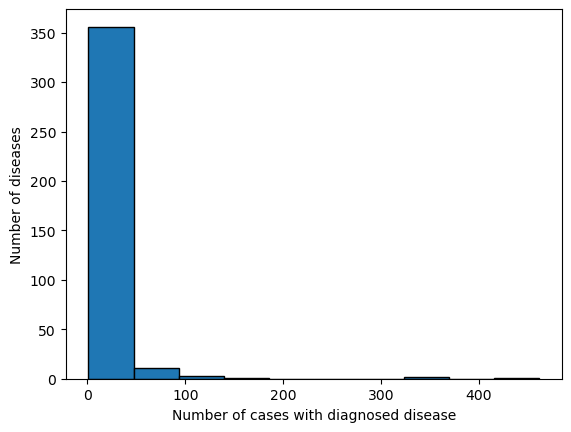

MONDO:0012812 462
MONDO:0013388 342
MONDO:0007846 333
MONDO:0012864 157
MONDO:0013446 113
MONDO:0007732 99
MONDO:0014198 95
MONDO:0032790 73
MONDO:0007838 69
MONDO:0007843 62
MONDO:0032702 60
MONDO:0014605 60
MONDO:0014936 52
MONDO:0011904 51
MONDO:0007947 50
MONDO:0009747 50
MONDO:0008287 50
MONDO:0957810 49
MONDO:0013426 47
MONDO:0009550 46
MONDO:0014213 46
MONDO:0032572 45
MONDO:0007514 44
MONDO:0007269 43
MONDO:0014533 43
MONDO:0021569 41
MONDO:0014262 41
MONDO:0007524 35
MONDO:0013897 34
MONDO:0010089 34
MONDO:0011706 33
MONDO:0033043 33
MONDO:0100082 31
MONDO:0011451 30
MONDO:0011683 30
MONDO:0957496 29
MONDO:0011614 29
MONDO:0958239 28
MONDO:0957813 28
MONDO:0008104 27
MONDO:0007943 25
MONDO:0009999 25
MONDO:0958196 24
None 23
MONDO:0014823 23
MONDO:0800306 22
MONDO:0013277 22
MONDO:0957812 22
MONDO:0012427 21
MONDO:0007804 21
MONDO:0008038 20
MONDO:0957815 20
MONDO:0011531 20
MONDO:0060760 20
MONDO:0032755 20
MONDO:0800130 20
MONDO:0013612 19
MONDO:0014857 19
MONDO:0010524 18
M

In [12]:
# Plot number of phenotypes 
fig = plt.figure()
ax = plt.subplot2grid((1,1), (0,0))
ax.hist(list(Counter([p.disease_mapped for p in phenopacket_data.values()]).values()), edgecolor='black')
ax.set_xlabel("Number of cases with diagnosed disease")
ax.set_ylabel("Number of disease")
plt.show()

tot = 0
for kk,vv in sorted([[k,v] for k,v in Counter([p.disease_mapped for p in phenopacket_data.values()]).items()], key=lambda x: x[1], reverse=True):
    print(kk,vv)

In [75]:
# Group patient data by disease id, and then randomly sample the relevant filepaths if the group is larger than 10
global_samplenames = {}#copy_files_flat_select(src_dir, dst_dir, suffix="*.parquet", match_names={})
for p in phenopacket_data.values():
    if p.disease_mapped not in global_samplenames:
        global_samplenames.update({p.disease_mapped:[]})
    global_samplenames[p.disease_mapped].append("{}.parquet".format(p.sample_name))

In [80]:
# Layout the filepaths for the results files that we want to copy to and from after downsampling
top_res_dir = "/work/users/a/o/ao33/ELDER/RESULTS"
elder_prefs = ["small3", "large3", "ada002", "bgem3", "mxbai", "nomic"]
elder_base_respref = "output/refined_disease_results"

exomiser_baseres = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results"

downsample_sample_log = "/work/users/a/o/ao33/ELDER/samplenames_downsample"

In [81]:
# Downsample and copy elder and exomiser results
elder_ddirs = [elder_downsample_dir1, elder_downsample_dir2, elder_downsample_dir3, elder2, elder3, elder4, elder5, elder6]
elder_bdirs = [elder_baseres, elder_baseres, elder_baseres, elder2_base, elder3_base, elder4_base, elder5_base, elder6_base]

exomiser_ddirs = [exomiser_downsample_dir1, exomiser_downsample_dir2, exomiser_downsample_dir3]
exomiser_bdirs = [exomiser_baseres, exomiser_baseres, exomiser_baseres]

# We want 3 trials for random downsampling
for trial_num in range(1, 4):
    print("- Processing downsample trial {}/{}".format(trial_num,3))
    
    # Produce a single list of downsampled names for all experiments for this run
    downsampled_names = downsample_results(global_samplenames, how_many=10)

    # Now downsample and copy elder results
    for pref in elder_prefs:
        base_dir = os.path.join(top_res_dir, pref, elder_base_respref)
        dst_dir = os.path.join(top_res_dir, pref, "output/refined_disease_results_downsample{}".format(trial_num))
        copy_files_flat_select(base_dir, dst_dir, suffix="*.parquet", match_names=downsampled_names)
        print(base_dir)
        print(dst_dir)
        print()


    # Now downsample exomiser results
    dst_dir = os.path.join(top_res_dir, "pstore_0.1.14_exomiser_default_merged", "refined_disease_results_downsample{}".format(trial_num))
    copy_files_flat_select(exomiser_baseres, dst_dir, suffix="*.parquet", match_names=downsampled_names)
    print(exomiser_baseres)
    print(dst_dir)

    # Log/write results
    outpath = "{}{}.txt".format(downsample_sample_log, trial_num)
    pd.DataFrame({"sample_name":list(downsampled_names.keys())}).to_csv(outpath, sep='\t', index=False)
    

- Processing downsample trial 1/3
- Copied 2049/2049
/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results
/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results_downsample1

- Copied 2049/2049
/work/users/a/o/ao33/ELDER/RESULTS/large3/output/refined_disease_results
/work/users/a/o/ao33/ELDER/RESULTS/large3/output/refined_disease_results_downsample1

- Copied 2049/2049
/work/users/a/o/ao33/ELDER/RESULTS/ada002/output/refined_disease_results
/work/users/a/o/ao33/ELDER/RESULTS/ada002/output/refined_disease_results_downsample1

- Copied 2049/2049
/work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/refined_disease_results
/work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/refined_disease_results_downsample1

- Copied 2049/2049
/work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/refined_disease_results
/work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/refined_disease_results_downsample1

- Copied 2049/2049
/work/users/a/o/ao33/ELDER/RESULTS/nomic/output/refined_disea

## Benchnmarking yaml config generation

In [42]:
def generate_benchmark_yaml(benchmark_name, runs, phenopacket_dir, outfilepath):
    """
    Generate YAML for a Pheval benchmark config.

    Parameters
    ----------
    benchmark_name : str
        Name of the benchmark.
    runs : iterable of dict
        Each dict must contain:
            - run_identifier
            - results_dir
    phenopacket_dir : str
        Shared phenopacket directory.

    Returns
    -------
    str
        YAML-formatted string.
    """
    config = {"benchmark_name": benchmark_name,
              "runs": [],
              "plot_customisation": {"gene_plots": {"plot_type": "bar_cumulative",
                                                    "rank_plot_title": None,
                                                    "roc_curve_title": None,
                                                    "precision_recall_title": None},
                                    
                                     "disease_plots": {"plot_type": "bar_cumulative",
                                                       "rank_plot_title": None,
                                                       "roc_curve_title": None,
                                                       "precision_recall_title": None},
                                    
                                     "variant_plots": {"plot_type": "bar_cumulative",
                                                       "rank_plot_title": None,
                                                       "roc_curve_title": None,
                                                       "precision_recall_title": None}}}


    for run in runs:
        config["runs"].append({"run_identifier": run["run_identifier"],
                               "results_dir": run["results_dir"],
                               "phenopacket_dir": phenopacket_dir,
                               "gene_analysis": False,
                               "variant_analysis": False,
                               "disease_analysis": True,
                               "threshold": None,
                               "score_order": "descending"})

    print("- Writing output as yaml to {}".format(outfilepath))
    yamtext = yaml.safe_dump(config, sort_keys=False, default_flow_style=False)
    with open(outfilepath, 'w') as outfile:
        outfile.write(yamtext)
        
    return yamtext

### Full dataset

In [180]:
# Build our input/output arguments for benchmarking yaml file that is required by pheval
# We need merged results directory from different runs, and we need benchmarking name to use for that run
# Note, we will need to rename "megatron" models to nemotron

# Benchmark params
benchmark_name = "exomiser_14.0.0_phenotype_only_mode"
base_pheno_packet_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged"
benchmark_yaml_path = "/work/users/a/o/ao33/ELDER/BENCHMARKING/elder_vs_exomiser_14.0.0_pstore_0.1.14_all_benchmark_config.yaml"

# Build results and exps names / filepaths dynamically
top_dir = "/work/users/a/o/ao33/ELDER/RESULTS"
exomiser_res_dir = "pstore_0.1.14_exomiser_default_merged/refined_disease_results"

config_run_order = ["exomiser_14.0",
                    "small3",
                    "nomic",
                    "mxbai",
                    "large3",
                    "bgem3",
                    "ada002"]


# Add version of phenopacketstore used, and create filepath string to all merged results directories to be used in experiment
# The results for elder runs get placed inside4 extra directories...
# From top level, we then get the following based on some of the input parameters as well (embedding size, and another...)
# nomic/output/pheval_disease_results/nomic_tpc_5084pp_top30000/nomic_tpc_nomic_hpo_5084pp_top30000/
#exp_prefixes = ["{}_{}".format(res_prefix, v) for v in exp_prefixes]
#res_dirs_formatted = [os.path.join(top_dir, "{}_merged".format(rdir)) for rdir in exp_prefixes]

# Generate a "config" for each experiment to use in the benchmarking
run_data_configs = []
for bname in config_run_order:
    
    r = ''
    # Select for elder runs by naming convention
    if not bname.startswith("exomiser_14"):
        r = os.path.join(top_dir, bname, "output", "refined_disease_results")

    elif bname.startswith("exomiser_14"):
        r = os.path.join(top_dir, exomiser_res_dir)
    
    bconfig = {"run_identifier": bname,
               "results_dir": r}

    print(bconfig)
    run_data_configs.append(bconfig)

{'run_identifier': 'exomiser_14.0', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results'}
{'run_identifier': 'small3', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results'}
{'run_identifier': 'nomic', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/nomic/output/refined_disease_results'}
{'run_identifier': 'mxbai', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/refined_disease_results'}
{'run_identifier': 'large3', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/large3/output/refined_disease_results'}
{'run_identifier': 'bgem3', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/refined_disease_results'}
{'run_identifier': 'ada002', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/ada002/output/refined_disease_results'}


In [181]:
# Now generate the benchmark yaml file to be used in pheval benchmarking command / script
bconfig = generate_benchmark_yaml(benchmark_name=benchmark_name, 
                                  runs=run_data_configs, 
                                  phenopacket_dir=base_pheno_packet_dir, 
                                  outfilepath=benchmark_yaml_path)

- Writing output as yaml to /work/users/a/o/ao33/ELDER/BENCHMARKING/elder_vs_exomiser_14.0.0_pstore_0.1.14_all_benchmark_config.yaml


### Downsampled to maximum of 10 patients per diagnosed disease

In [82]:
# Build our input/output arguments for benchmarking yaml file that is required by pheval
# We need merged results directory from different runs, and we need benchmarking name to use for that run
# Note, we will need to rename "megatron" models to nemotron


for trial_num in range(1, 4):

    # Benchmark params
    benchmark_name = "exomiser_14.0.0_phenotype_only_mode"
    base_pheno_packet_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged"
    benchmark_yaml_path = "/work/users/a/o/ao33/ELDER/BENCHMARKING/elder_vs_exomiser_all_downsample{}.yaml".format(trial_num)
    
    # Build results and exps names / filepaths dynamically
    top_dir = "/work/users/a/o/ao33/ELDER/RESULTS"
    exomiser_res_dir = "pstore_0.1.14_exomiser_default_merged/refined_disease_results_downsample{}".format(trial_num)
    
    config_run_order = ["exomiser_14.0",
                        "small3",
                        "nomic",
                        "mxbai",
                        "large3",
                        "bgem3",
                        "ada002"]
    
    
    # Add version of phenopacketstore used, and create filepath string to all merged results directories to be used in experiment
    # The results for elder runs get placed inside4 extra directories...
    # From top level, we then get the following based on some of the input parameters as well (embedding size, and another...)
    # nomic/output/pheval_disease_results/nomic_tpc_5084pp_top30000/nomic_tpc_nomic_hpo_5084pp_top30000/
    #exp_prefixes = ["{}_{}".format(res_prefix, v) for v in exp_prefixes]
    #res_dirs_formatted = [os.path.join(top_dir, "{}_merged".format(rdir)) for rdir in exp_prefixes]
    
    # Generate a "config" for each experiment to use in the benchmarking
    run_data_configs = []
    for bname,rname in zip(config_run_order, run_names):
        
        r = ''
        # Select for elder runs by naming convention
        if not bname.startswith("exomiser_14"):
            r = os.path.join(top_dir, bname, "output", "refined_disease_results_downsample{}".format(trial_num))
    
        elif bname.startswith("exomiser_14"):
            r = os.path.join(top_dir, exomiser_res_dir)
        
        bconfig = {"run_identifier": bname,
                   "results_dir": r}
    
        print(bconfig)
        run_data_configs.append(bconfig)

    # Now generate the benchmark yaml file to be used in pheval benchmarking command / script
    bconfig = generate_benchmark_yaml(benchmark_name=benchmark_name, 
                                      runs=run_data_configs, 
                                      phenopacket_dir=base_pheno_packet_dir, 
                                      outfilepath=benchmark_yaml_path)

{'run_identifier': 'exomiser_14.0', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results_downsample1'}
{'run_identifier': 'small3', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results_downsample1'}
{'run_identifier': 'nomic', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/nomic/output/refined_disease_results_downsample1'}
{'run_identifier': 'mxbai', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/refined_disease_results_downsample1'}
{'run_identifier': 'large3', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/large3/output/refined_disease_results_downsample1'}
{'run_identifier': 'bgem3', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/refined_disease_results_downsample1'}
{'run_identifier': 'ada002', 'results_dir': '/work/users/a/o/ao33/ELDER/RESULTS/ada002/output/refined_disease_results_downsample1'}
- Writing output as yaml to /work/users/a/o/ao33/EL

## Compile results into single datastructure and dataframe

In [33]:
def parquet_results_to_rank(res_path):
    df = (pl.scan_parquet(res_path, include_file_paths="file")
        .filter(pl.col("true_positive"))
        
        # dedupe within each file
        .group_by(["file", "mondo_identifier"])
        .agg(pl.col("rank").min().alias("rank")) # We take the row with the smallest rank (i.e. best)
    )
    df = df.collect().to_pandas()
    r = 0
    if len(df["rank"]) > 0:
        r = df["rank"][0]
    return r


def load_disease_hpo_map(filepath):
    """
    Parse an HPO annotation file and return:
    { database_id: { hpo_id: "" , ... }, ... }
    """
    
    disease_map = {}
    header = 0
    with open(filepath, "r") as f:
        for line in f:
            # Skip comments and empty lines
            if not line.strip() or line.startswith("#"):
                
                continue

            # Assume header is first non "#" character line
            if header == 0:
                header_info = {n:i for i,n in enumerate(line.strip('\r').strip('\n').split('\t'))}
                header = 1
            
            
            fields = line.rstrip("\n").split("\t")

            database_id = fields[header_info["database_id"]]
            hpo_id = fields[header_info["hpo_id"]]

            if database_id not in disease_map:
                disease_map[database_id] = {}

            disease_map[database_id][hpo_id] = ""

    return disease_map

- Need to compile information across each sample for the following
  - Phenotype classification group
  - Disease (disease phenpotype) classification group
  - Downsample1 group
  - Downsample2 group
  - Downsample3 group
  - Elder top1
  - Elder top3
  - Elder top5
  - Elder top10
  - Elder mmr
  - Exomiser top1
  - Exomiser top3
  - Exomiser top5
  - Exomiser top10
  - Exomiser mmr

In [101]:
# Gather original phenopacket info and disease identifiers
og_phenopacket_dir = "/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.14_merged/phenopackets/"
mondo_sssom_path = "/work/users/a/o/ao33/MONDO/mondo.sssom.tsv"
hpoa_fpath = "/work/users/a/o/ao33/HPOA/phenotype.hpoa"
hgnc_path = "/work/users/a/o/ao33/HGNC/hgnc_complete_set.txt"

# # All data
# #elder_resdir = "/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results"
# #exomiser_resdir = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results"

# # Downsampled data
# elder_resdir = "/work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results_downsample3"
# exomiser_resdir = "/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results_downsample3"


# Generate mapping tables to mondo disease identifiers, and hgnc gene identifiers
mondo_mapping = read_mondo_sssom_to_mapping_table(mondo_sssom_path, match_pred="skos:exactMatch")
hgnc_mapping, hgnc_ambiguous = read_hgnc_to_mapping_table(hgnc_path)

# Gather phenopacket filepaths and "sample names" 
process_data = {f.split("/")[-1].replace(".json", ""):os.path.join(og_phenopacket_dir, f) 
                for f in os.listdir(og_phenopacket_dir) if f.endswith(".json")}

print("- Found {} phenopackets ending in .json".format(format(len(process_data), ',')))
phenopacket_data = phenopacket_paths_to_data(process_data, disease_map=mondo_mapping, gene_map=hgnc_mapping)

# Phenotypes per disease
raw_hpo_map = load_disease_hpo_map(hpoa_fpath)
hpo_map = {mondo_mapping.get(h, h):v for h,v in raw_hpo_map.items()}

- 163,148 Total terms mapping to 24,222 subject ids...
- Found 399,537 terms mapping to 44,117 unique hgnc ids
- Found 2,277 ambigous terms
- Found 5,084 phenopackets ending in .json
- 1,000/5,084 phenopackets read into memory...
- 2,000/5,084 phenopackets read into memory...
- 3,000/5,084 phenopackets read into memory...
- 4,000/5,084 phenopackets read into memory...
- 5,000/5,084 phenopackets read into memory...
- Multi gene diagnosis phenopackets found 0...
- Multi disease diagnosis phenopackets found 0...
- 5,084 Phenopackets information read into memory...


In [102]:
#######################################
### Add phenotype group information ###

# First create list of sample objects and add specific information to them 
# regarding phenotype classiciation and disease group classifications
# Add grouping information here based on phenotype counts

for k in phenopacket_data:
    p = phenopacket_data[k]
    if 10 >= p.phenotype_count >= 1:
        pgroup = "1-10"
        
    elif 20 >= p.phenotype_count > 10:
        pgroup = "10-20"


    elif 30 >= p.phenotype_count > 20:
        pgroup = "20-30"


    elif p.phenotype_count > 30:
        pgroup = "30+"

    else:
        raise ValueError("- ERROR phenotype count data is off for {}...".format(p.phenopacket_path))
    
    
    # elif 40 >= p.phenotype_count > 30:
    #     pgroup = "30-40"


    # elif p.phenotype_count > 40:
    #     pgroup = "40+"
        
    p.p_group = pgroup

In [103]:
#####################################
### Add disease group information ###

# Now we find the set of diseases that is found only in our patient data
patient_dids = set([p.disease_mapped if p.disease_mapped else p.disease_id for p in phenopacket_data.values()])
global_dids = set(list(hpo_map.keys()))
common_dids = patient_dids & global_dids
missing = patient_dids-common_dids
print("- Total patient disease ids found {}".format(format(len(patient_dids), ',')))
print("- Common disease ids found between hpo set and patient {}".format(format(len(common_dids), ',')))
print("- Missing data {}, -- {}".format(len(patient_dids-common_dids), patient_dids-common_dids))
for k in missing:
    if k in raw_hpo_map:
        print(k)


# Pull out only phenopackets belonging to these diseases
select_pdata = set([k for k,p in phenopacket_data.items() if (p.disease_id in common_dids) or (p.disease_mapped in common_dids)])
print("- {}/{} patient data remaining".format(len(select_pdata), len(phenopacket_data)))


# Add grouping information here based on diagnosed disease phenotype annotation counts
disease_pgroups = {}
for c in common_dids:
    if 10 >= len(hpo_map[c]) >= 1:
        pgroup = "1-10"
        
    elif 20 >= len(hpo_map[c]) > 10:
        pgroup = "10-20"


    elif 30 >= len(hpo_map[c]) > 20:
        pgroup = "20-30"


    elif 40 >= len(hpo_map[c]) > 30:
        pgroup = "30-40"


    elif len(hpo_map[c]) > 40:
        pgroup = "40+"

    else:
        raise ValueError("- ERROR unkown datatype for hpo_map...")
        
    disease_pgroups[c] = pgroup

# Now add this bit of information to our patient data
for k in select_pdata:
    p = phenopacket_data[k]
    p.d_group = disease_pgroups[p.disease_mapped]

- Total patient disease ids found 378
- Common disease ids found between hpo set and patient 373
- Missing data 5, -- {'OMIM:608910', 'OMIM:608909', 'OMIM:608912', 'OMIM:608913', 'OMIM:601674'}
- 5061/5084 patient data remaining


In [104]:
# Now add in downsample group information (0 for no, and 1 for yes)
ds1_df = set(list(pd.read_csv("/work/users/a/o/ao33/ELDER/samplenames_downsample1.txt", sep="\t")["sample_name"]))
ds2_df = set(list(pd.read_csv("/work/users/a/o/ao33/ELDER/samplenames_downsample2.txt", sep="\t")["sample_name"]))
ds3_df = set(list(pd.read_csv("/work/users/a/o/ao33/ELDER/samplenames_downsample3.txt", sep="\t")["sample_name"]))

scount1,scount2,scount3 = 0,0,0
for k in phenopacket_data:
    
    p = phenopacket_data[k]
    p.downsample1 = 0
    p.downsample2 = 0
    p.downsample3 = 0

    sname = "{}.parquet".format(p.sample_name)
    if sname in ds1_df:
        p.downsample1 = 1
        scount1 += 1

    if sname in ds2_df:
        p.downsample2 = 1
        scount2 += 1

    if sname in ds3_df:
        p.downsample3 = 1
        scount3 += 1

print("- Downsample1 files/samples found {}".format(scount1))
print("- Downsample2 files/samples found {}".format(scount2))
print("- Downsample3 files/samples found {}".format(scount3))

- Downsample1 files/samples found 2049
- Downsample2 files/samples found 2049
- Downsample3 files/samples found 2049


In [105]:
elder_res_prefs = ["small3",
                   "large3",
                   "mxbai",
                   "nomic",
                   "bgem3",
                   "ada002"]

res_prefs = ["ELDER-{}".format(e) for e in elder_res_prefs]
res_dirs = ["/work/users/a/o/ao33/ELDER/RESULTS/{}/output/refined_disease_results".format(e) for e in elder_res_prefs]

# Now add exomiser results information
res_dirs.append("/work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disease_results")
res_prefs.append("ontology-only")

index = 0
for rname,res_dir in zip(res_prefs, res_dirs):

    print("- Processing results directory for {}, {}".format(rname, res_dir))

    fpaths = [os.path.join(res_dir, fname) for fname in os.listdir(res_dir) if fname.endswith(".parquet")]
    snames = [f.split('/')[-1].split(".parquet")[0] for f in fpaths]

    # Sanity check to make sure all our sample names match up with what we currently have in memory
    found = 0
    for sname in snames:
        if sname not in phenopacket_data:
            print("  - WARNING / ERROR, {} not found in current set of data...".format(sname))
        else:
            found += 1

    print("  - Samples found {}".format(found))
    ranks = [parquet_results_to_rank(f) for f in fpaths]

    # Now update our patient objects with the rank they were given by the prioritizer algorithm (elder or exomiser)
    for sname,r in zip(snames, ranks):
        p = phenopacket_data[sname]
        if not p.results:
            p.results = {}
        p.results.update({rname:r})
        

- Processing results directory for ELDER-small3, /work/users/a/o/ao33/ELDER/RESULTS/small3/output/refined_disease_results
  - Samples found 5084
- Processing results directory for ELDER-large3, /work/users/a/o/ao33/ELDER/RESULTS/large3/output/refined_disease_results
  - Samples found 5084
- Processing results directory for ELDER-mxbai, /work/users/a/o/ao33/ELDER/RESULTS/mxbai/output/refined_disease_results
  - Samples found 5084
- Processing results directory for ELDER-nomic, /work/users/a/o/ao33/ELDER/RESULTS/nomic/output/refined_disease_results
  - Samples found 5084
- Processing results directory for ELDER-bgem3, /work/users/a/o/ao33/ELDER/RESULTS/bgem3/output/refined_disease_results
  - Samples found 5084
- Processing results directory for ELDER-ada002, /work/users/a/o/ao33/ELDER/RESULTS/ada002/output/refined_disease_results
  - Samples found 5084
- Processing results directory for ontology-only, /work/users/a/o/ao33/ELDER/RESULTS/pstore_0.1.14_exomiser_default_merged/refined_disea

In [118]:
# Now turn our data into a dataframe and write out
# Initial datastructure to hold data
global_res = {k:[] for k in list(phenopacket_data.values())[0].__dict__}
alg_results = {k:[] for k in list(phenopacket_data.values())[0].results}
print(global_res)

{'sample_name': [], 'phenopacket_path': [], 'phenotype_ids': [], 'phenotype_count': [], 'disease_name': [], 'disease_id': [], 'gene_symbol': [], 'gene_id': [], 'disease_mapped': [], 'gene_mapped': [], 'p_group': [], 'd_group': [], 'downsample1': [], 'downsample2': [], 'downsample3': [], 'results': []}


In [119]:
# Add all the results data (Note, all objects have all attributes even if they are None type) 
for k in phenopacket_data:

    # Each row of our outputfile will be a patient phenopackets information in tabular form along with the algorithm(s) results
    p = phenopacket_data[k]
    for k in p.__dict__:
        if k != "results":

            # Format these into a comma separated list. Nicer file to work with downstream
            # Irregular data types that pandas handles just fine, but make other tools break (awk, cut...)
            # Some data fields (like the disease human readable name) can have tab separators in them and we do not want this
            # So we replace with space instead
            
            if k == "phenotype_ids":
                global_res[k].append(','.join(p.phenotype_ids))
            else:
                attr = getattr(p, k)
                if type(attr) == type(''):
                    attr = attr.replace("\t", " ")
                global_res[k].append(attr)
        
        else:
            for algname in alg_results:
                alg_results[algname].append(p.results[algname])


In [120]:
# Now turn into dataframe and write
compiled_data_outfile = "/work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv"
del global_res["results"] # No longer needed 
global_res.update(alg_results)
pd.DataFrame(global_res).to_csv(compiled_data_outfile, sep='\t', index=False)

In [123]:
res_df = pd.read_csv(compiled_data_outfile, sep='\t')
display(res_df)

,sample_name,phenopacket_path,phenotype_ids,phenotype_count,disease_name,disease_id,gene_symbol,gene_id,disease_mapped,gene_mapped,...,downsample1,downsample2,downsample3,ELDER-small3,ELDER-large3,ELDER-mxbai,ELDER-nomic,ELDER-bgem3,ELDER-ada002,ontology-only
0,PMID_10571775_KSN-II-1,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0001510,HP:0002900,HP:0004918,HP:0032944,HP...",8,Distal renal tubular acidosis 4 with hemolytic...,OMIM:611590,SLC4A1,HGNC:11027,MONDO:0012700,HGNC:11027,...,1,1,1,7,6,7,5,6,6,3
1,PMID_10571775_YAT-II-1,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0001510,HP:0002900,HP:0004918,HP:0032944,HP...",8,Distal renal tubular acidosis 4 with hemolytic...,OMIM:611590,SLC4A1,HGNC:11027,MONDO:0012700,HGNC:11027,...,1,1,1,7,6,7,5,6,6,3
2,PMID_10580070_A_III-1,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0001644,HP:0001709",2,"Cardiomyopathy, dilated, 1A",OMIM:115200,LMNA,HGNC:6636,MONDO:0007269,HGNC:6636,...,1,1,0,3,3,3,3,3,3,1
3,PMID_10580070_A_III-11,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0005110,HP:0003236,HP:0011706",3,"Cardiomyopathy, dilated, 1A",OMIM:115200,LMNA,HGNC:6636,MONDO:0007269,HGNC:6636,...,1,0,1,22,7,10,15,7,15,1
4,PMID_10580070_A_III-13,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0005110,HP:0001688,HP:0011705",3,"Cardiomyopathy, dilated, 1A",OMIM:115200,LMNA,HGNC:6636,MONDO:0007269,HGNC:6636,...,0,1,0,2,2,2,2,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5079,PMID_9817917_Family8individual13073,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0000819,HP:0000648,HP:0000126,HP:0001251,HP...",5,Wolfram syndrome 1,OMIM:222300,WFS1,HGNC:12762,MONDO:0009101,HGNC:12762,...,1,1,1,1,1,1,1,1,1,1
5080,PMID_9817917_Family9individual13781,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0000873,HP:0000819,HP:0000648,HP:0000126,HP...",5,Wolfram syndrome 1,OMIM:222300,WFS1,HGNC:12762,MONDO:0009101,HGNC:12762,...,1,1,1,1,1,1,1,1,1,1
5081,PMID_9854053_II2,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0004322,HP:0004325,HP:0000980,HP:0001744,HP...",18,Distal renal tubular acidosis 4 with hemolytic...,OMIM:611590,SLC4A1,HGNC:11027,MONDO:0012700,HGNC:11027,...,1,1,1,1,1,1,1,1,1,1
5082,PMID_9854053_II3,/work/users/a/o/ao33/PHENOPACKETS/pstore_0.1.1...,"HP:0004322,HP:0004325,HP:0002900,HP:0004918,HP...",14,Distal renal tubular acidosis 4 with hemolytic...,OMIM:611590,SLC4A1,HGNC:11027,MONDO:0012700,HGNC:11027,...,1,1,1,1,1,1,1,1,1,1


## Wilcoxon test and confidence intervals for top1 performance differences

In [29]:
from scipy.stats import bootstrap
from scipy.stats import wilcoxon

In [30]:
# The function is originally from the phenotype and disease phenotype stratification sections of the notebook
def parquet_results_to_rank(res_path):
    df = (pl.scan_parquet(res_path, include_file_paths="file")
        .filter(pl.col("true_positive"))
        
        # dedupe within each file
        .group_by(["file", "mondo_identifier"])
        .agg(pl.col("rank").min().alias("rank")) # We take the row with the smallest rank (i.e. best)
    )
    df = df.collect().to_pandas()
    r = 0
    if len(df["rank"]) > 0:
        r = df["rank"][0]
    return r


# statistic must accept arrays and an axis argument if vectorized=True
def stat(a, b, axis=0):
    return a.mean(axis=axis) - b.mean(axis=axis)


def resdir_to_top1_array(results_dir):
    res = []
    for f in os.listdir(results_dir):
        inpath = os.path.join(results_dir, f)
        rank = parquet_results_to_rank(inpath)
        if rank != 1:
            rank = 0
        res.append(rank)

    return np.array(res)


In [31]:
# Load our entire results dataframe which has all our grouping information, and results rankings for each algorithm
compiled_data_outfile = "/work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv"
res_df = pd.read_csv(compiled_data_outfile, sep='\t')

In [32]:
# Generate a dictionary of data arrays to compare against one another for our two algorithm groups
alg1 = "ELDER-small3"
alg2 = "ontology-only"

downsample_groups = ["downsample1", "downsample2", "downsample3"]
p_groups = ["1-10","10-20","20-30","30+"]
d_groups = ["1-10","10-20","20-30","30-40","40+"]
top_sig_groups = ["top1", "top3", "top5", "top10"]

tot_samples = len(res_df["sample_name"])
elder_res = {}
exomiser_res = {}

In [33]:
# Update global comparison
elder_res.update({"global":np.array(list(res_df[alg1])).astype(int)})
exomiser_res.update({"global":np.array(list(res_df[alg2])).astype(int)})

In [34]:
# Update groups for top1,top3,top5,top10 across all samples
for t_group in top_sig_groups:
    elder_res.update({("global", t_group):np.array(list(res_df[alg1])).astype(int)})
    exomiser_res.update({("global", t_group):np.array(list(res_df[alg2])).astype(int)})

In [35]:
# Update global downsampled comparisons
for ds_group in downsample_groups:
    
    sample_inds = []
    for i in range(0, tot_samples):
        if res_df[ds_group][i] == 1:
            sample_inds.append(i)

    elder_res.update({ds_group:np.array(list(res_df[alg1])).astype(int)[sample_inds]})
    exomiser_res.update({ds_group:np.array(list(res_df[alg2])).astype(int)[sample_inds]})


In [36]:
# Update global downsampled (we convert ranks to 0 or 1 later)
for ds_group in downsample_groups:
    for t_group in top_sig_groups:
        sample_inds = []
        for i in range(0, tot_samples):
            if res_df[ds_group][i] == 1:
                sample_inds.append(i)

        elder_res.update({(ds_group, t_group):np.array(list(res_df[alg1])).astype(int)[sample_inds]})
        exomiser_res.update({(ds_group, t_group):np.array(list(res_df[alg2])).astype(int)[sample_inds]})


In [37]:
# For patient phenotype grouping (all data)
for p_group in p_groups:
    sample_inds = []
    for i in range(0, tot_samples):
        if res_df["p_group"][i] == p_group:
            sample_inds.append(i)

    elder_res.update({("global", "patient-phenotype:{}".format(p_group)):np.array(list(res_df[alg1])).astype(int)[sample_inds]})
    exomiser_res.update({("global", "patient-phenotype:{}".format(p_group)):np.array(list(res_df[alg2])).astype(int)[sample_inds]})


# For patient disease diagonsis grouping (actual diagnosis, not predicted) (all data)
for d_group in d_groups:
    sample_inds = []
    for i in range(0, tot_samples):
        if res_df["d_group"][i] == d_group:
            sample_inds.append(i)

    elder_res.update({("global", "disease-phenotype:{}".format(d_group)):np.array(list(res_df[alg1])).astype(int)[sample_inds]})
    exomiser_res.update({("global", "disease-phenotype:{}".format(d_group)):np.array(list(res_df[alg2])).astype(int)[sample_inds]})
    

In [38]:
# Now make the results array data for downsampled+phenotype/disease groupings
tot_samples = len(res_df["sample_name"])
for ds_group in downsample_groups:

    # For patient phenotype grouping
    for p_group in p_groups:
        sample_inds = []
        for i in range(0, tot_samples):
            if (res_df["p_group"][i] == p_group) and (res_df[ds_group][i] == 1):
                sample_inds.append(i)

        
        elder_res.update({(ds_group, "patient-phenotype:{}".format(p_group)):np.array(list(res_df[alg1])).astype(int)[sample_inds]})
        exomiser_res.update({(ds_group, "patient-phenotype:{}".format(p_group)):np.array(list(res_df[alg2])).astype(int)[sample_inds]})


    # For patient disease diagonsis grouping (actual diagnosis, not predicted)

    for d_group in d_groups:
        sample_inds = []
        for i in range(0, tot_samples):
            if (res_df["d_group"][i] == d_group) and (res_df[ds_group][i] == 1):
                sample_inds.append(i)

        
        elder_res.update({(ds_group, "disease-phenotype:{}".format(d_group)):np.array(list(res_df[alg1])).astype(int)[sample_inds]})
        exomiser_res.update({(ds_group, "disease-phenotype:{}".format(d_group)):np.array(list(res_df[alg2])).astype(int)[sample_inds]})

In [163]:
# Now compute confidence intervals and wilcoxon pvalue
n_resamples = 10_000
alpha = .05
seed = 1

stats_outfile = "/work/users/a/o/ao33/ELDER/stats_analsysis.tsv"
comparison_results = {"comparison_name":[],
                      "wilcox_pvalue":[],
                      "wilcox_stat":[],
                      "ci_high":[],
                      "ci_low":[],
                      "n_samples":[],
                      "rr_wilcox_pvalue":[],
                      "rr_wilcox_stat":[],
                      "rr_ci_high":[],
                      "rr_ci_low":[]} ## rr_ is for "reciprocal rank"


for k in elder_res:
    print(k, elder_res[k].shape)
    print(k, exomiser_res[k].shape)
    print()

    # Last step, we must convert our ranks, into 0,1 arrays (0 for anything but top rank, and 1 for the top rank)

    if "top" in k[1]:
        topk = int(k[1].replace("top", ""))
    else:
        topk = 1
                
    res1 = np.array([1 if (e <= topk) and (e > 0) else 0 for e in elder_res[k]])
    res2 = np.array([1 if (e <= topk) and (e > 0) else 0 for e in exomiser_res[k]])

    rr_res1 = np.array([1./float(e) if e > 0 else 0 for e in elder_res[k]])
    rr_res2 = np.array([1./float(e) if e > 0 else 0 for e in exomiser_res[k]])

    if len(res1) <= 1:
        print("- Skipping {}... N={}<=1 which is too small of a smaple size".format(k, len(res1)))
        continue

    if (len(np.argwhere(res1 == 1).flatten()) == 0) and (len(np.argwhere(res2 == 1).flatten()) == 0):
        print("- Skipping {}... All results elements are zero for both algorithms".format(k, len(res1)))
        continue

    # Confidence intervals
    print("- grouped samples {}".format(len(res1)))
    res = bootstrap(data=(res1, res2),
                    statistic=stat,
                    paired=True,
                    n_resamples=n_resamples,
                    confidence_level=1 - alpha,
                    method="BCa",
                    random_state=seed,
                    vectorized=True)

    
    # Confidence intervals (reciprocal)
    print("- grouped samples {}".format(len(res1)))
    rr_res = bootstrap(data=(rr_res1, rr_res2),
                             statistic=stat,
                             paired=True,
                             n_resamples=n_resamples,
                             confidence_level=1 - alpha,
                             method="BCa",
                             random_state=seed,
                             vectorized=True)

    
    ci_low = float(res.confidence_interval.low)
    ci_high = float(res.confidence_interval.high)

    rr_ci_low = float(rr_res.confidence_interval.low)
    rr_ci_high = float(rr_res.confidence_interval.high)
    print(ci_low, ci_high)

    # Wilcoxon test pvalue
    # Paired wilcoxon test
    d = res1 - res2  # per-case differences: -1,0,+1
    rr_d = rr_res1 - rr_res2  # per-case differences: -1,0,+1
    
    # Wilcoxon signed-rank test is defined on paired differences.
    w = wilcoxon(d, zero_method="wilcox", alternative="two-sided", mode="auto")
    rr_w = wilcoxon(rr_d, zero_method="wilcox", alternative="two-sided", mode="auto")
    
    print("Wilcoxon statistic:", w.statistic)
    print("Wilcoxon p-value:", w.pvalue)
    comparison_results["comparison_name"].append(k)
    comparison_results["wilcox_pvalue"].append(w.pvalue)
    comparison_results["wilcox_stat"].append(w.statistic)
    comparison_results["ci_high"].append(ci_low)
    comparison_results["ci_low"].append(ci_high)
    comparison_results["n_samples"].append(len(res1))
    comparison_results["rr_wilcox_pvalue"].append(rr_w.pvalue)
    comparison_results["rr_wilcox_stat"].append(rr_w.statistic)
    comparison_results["rr_ci_high"].append(rr_ci_low)
    comparison_results["rr_ci_low"].append(rr_ci_high)

pd.DataFrame(comparison_results).to_csv(stats_outfile, sep='\t', index=False)
    

global (5084,)
global (5084,)

- grouped samples 5084
- grouped samples 5084
0.005114083398898496 0.03284815106215577
Wilcoxon statistic: 399760.0
Wilcoxon p-value: 0.006861085298968386
('global', 'top1') (5084,)
('global', 'top1') (5084,)

- grouped samples 5084
- grouped samples 5084
0.005114083398898496 0.03284815106215577
Wilcoxon statistic: 399760.0
Wilcoxon p-value: 0.006861085298968386
('global', 'top3') (5084,)
('global', 'top3') (5084,)

- grouped samples 5084
- grouped samples 5084
0.01435877261998425 0.04209284028324156
Wilcoxon statistic: 371737.5
Wilcoxon p-value: 7.797321457110701e-05
('global', 'top5') (5084,)
('global', 'top5') (5084,)

- grouped samples 5084
- grouped samples 5084
0.011605035405192754 0.03914240755310777
Wilcoxon statistic: 399000.0
Wilcoxon p-value: 0.0004023076949941896
('global', 'top10') (5084,)
('global', 'top10') (5084,)

- grouped samples 5084
- grouped samples 5084
-0.001942396657862653 0.025570416994492584
Wilcoxon statistic: 383238.0
Wilcoxon

/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/nas/longleaf/rhel9/apps/anaconda/2024.02.ood/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


- grouped samples 779
-0.0410783055198973 0.02439024390243902
Wilcoxon statistic: 6198.5
Wilcoxon p-value: 0.6352562959972483
('global', 'disease-phenotype:20-30') (758,)
('global', 'disease-phenotype:20-30') (758,)

- grouped samples 758
- grouped samples 758
-0.05540897097625336 0.02506596306068598
Wilcoxon statistic: 13560.0
Wilcoxon p-value: 0.40040390488905453
('global', 'disease-phenotype:30-40') (1288,)
('global', 'disease-phenotype:30-40') (1288,)

- grouped samples 1288
- grouped samples 1288
-0.0753105590062112 -0.022515527950310532
Wilcoxon statistic: 18028.5
Wilcoxon p-value: 0.00023069867099394532
('global', 'disease-phenotype:40+') (2027,)
('global', 'disease-phenotype:40+') (2027,)

- grouped samples 2027
- grouped samples 2027
0.07054760730143067 0.1149481993093241
Wilcoxon statistic: 48956.5
Wilcoxon p-value: 8.578376578154941e-16
('downsample1', 'patient-phenotype:1-10') (1374,)
('downsample1', 'patient-phenotype:1-10') (1374,)

- grouped samples 1374
- grouped sample

In [164]:
display(pd.DataFrame(comparison_results))

,comparison_name,wilcox_pvalue,wilcox_stat,ci_high,ci_low,n_samples,rr_wilcox_pvalue,rr_wilcox_stat,rr_ci_high,rr_ci_low
0,global,6.861085e-03,399760.0,0.005114,0.032848,5084,2.833331e-01,3502922.0,0.006661,0.030415
1,"(global, top1)",6.861085e-03,399760.0,0.005114,0.032848,5084,2.833331e-01,3502922.0,0.006661,0.030415
2,"(global, top3)",7.797321e-05,371737.5,0.014359,0.042093,5084,2.833331e-01,3502922.0,0.006661,0.030415
3,"(global, top5)",4.023077e-04,399000.0,0.011605,0.039142,5084,2.833331e-01,3502922.0,0.006661,0.030415
4,"(global, top10)",9.199477e-02,383238.0,-0.001942,0.025570,5084,2.833331e-01,3502922.0,0.006661,0.030415
5,downsample1,2.838440e-09,87153.5,0.051733,0.100049,2049,1.610648e-11,298210.5,0.056505,0.097620
6,downsample2,9.728630e-09,91447.5,0.048804,0.098585,2049,8.815873e-12,303329.5,0.056630,0.097601
7,downsample3,8.350014e-10,86016.0,0.052709,0.101513,2049,1.732624e-14,284008.0,0.062351,0.102195
8,"(downsample1, top1)",2.838440e-09,87153.5,0.051733,0.100049,2049,1.610648e-11,298210.5,0.056505,0.097620
9,"(downsample1, top3)",4.390122e-14,52636.5,0.064910,0.109810,2049,1.610648e-11,298210.5,0.056505,0.097620


In [92]:
display(pd.DataFrame(comparison_results))

,comparison_name,wilcox_pvalue,wilcox_stat,ci_high,ci_low,n_samples
0,global,6.861085e-03,399760.0,0.005114,0.032848,5084
1,"(global, top1)",6.861085e-03,399760.0,0.005114,0.032848,5084
2,"(global, top3)",7.797321e-05,371737.5,0.014359,0.042093,5084
3,"(global, top5)",4.023077e-04,399000.0,0.011605,0.039142,5084
4,"(global, top10)",9.199477e-02,383238.0,-0.001942,0.025570,5084
5,"(downsample1, top1)",2.838440e-09,87153.5,0.051733,0.100049,2049
6,"(downsample1, top3)",4.390122e-14,52636.5,0.064910,0.109810,2049
7,"(downsample1, top5)",4.091961e-13,50864.0,0.060517,0.104929,2049
8,"(downsample1, top10)",2.319377e-10,39900.0,0.046852,0.088336,2049
9,"(downsample2, top1)",9.728630e-09,91447.5,0.048804,0.098585,2049


## Benchmarking all runs

In [270]:
# General imports
import os
import argparse
import copy
import multiprocessing as mp
from pathlib import Path
from typing import List, Set
from collections import Counter
import pandas as pd
import numpy as np
from typing import List, Set, Optional
from pydantic import BaseModel

# Pheval phenopacket utils
from pheval.utils.phenopacket_utils import phenopacket_reader
from pheval.utils.phenopacket_utils import PhenopacketUtil

# Allows us to silence logging for pheval phenopacket reading
import logging
logging.getLogger().setLevel(logging.ERROR)

In [274]:
def get_nice_colormap(how_many):
    
    colors = []
    if how_many <= 20:
        cmap = plt.get_cmap("tab20")
        colors.extend(cmap.colors)

    elif (how_many > 20) and (how_many < 60):
        cmap = plt.get_cmap("tab20b")
        colors.extend(cmap.colors)

    elif how_many >= 60:
        cmap = plt.get_cmap("tab20c")
        colors.extend(cmap.colors)

    else:
        cmap = plt.cm.viridis
        colors = cmap(np.linspace(0, 1, n_runs))

    return colors[0:how_many]

# Same function used in benchmarking all runs section of the notebook
def add_pvalue_brackets(ax, bars_a, bars_b, pvals, pad=0.03, h=0.02, fs=9, total_samples=[], show_nonsig=True, show_pvals=True, percent_space=False):
    def p_to_stars(p):
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "ns"

    if percent_space == True:
        pad = pad * 40.
        h = h * 40.

    for i, p in enumerate(pvals):
        b1, b2 = bars_a[i], bars_b[i]
        x1 = b1.get_x() + b1.get_width()/2
        x2 = b2.get_x() + b2.get_width()/2
        h1,h2 = b1.get_height(), b2.get_height()
        y = max(h1, h2)
        y0 = y + pad

        # Generate text for plotting
        if len(total_samples) == len(pvals):
            p1 = "n={}{}".format(total_samples[i], '\n')

        else:
            p1 = ""

        if show_pvals == True:
            p2 = f"p={p:.2e} {p_to_stars(p)}"
        else:
            p2 = "{}".format(p_to_stars(p))

        ann = "{}{}".format(p1,p2)

        # Plot lines (outsidex, insidex, insidex, outsidex)
        if show_nonsig == False and p_to_stars(p) == "ns":
            ax.text((x1+x2)/2, y0, p1, ha="center", va="bottom", fontsize=fs,snap=True)
            continue

        
        
        ax.plot([x1, x1, x2, x2], [h1+h*2, y0+h, y0+h, h2+h*2], lw=1, c="black")
        ax.text((x1+x2)/2, y0+h, ann, ha='center', va="bottom", fontsize=fs,snap=True)

In [339]:
res_filepath = "/work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv"
stats_filepath = "/work/users/a/o/ao33/ELDER/stats_analsysis.tsv"
fig_dir = "/work/users/a/o/ao33/ELDER/FIGURES_NEW"
downsample = 3
os.makedirs(fig_dir, exist_ok=True)

# Format output names/paths for All data
if not downsample:
    # All data
    save_stats_name = "figure3_elder_vs_exomiser_allsamples.tsv"
    save_fig_name = "figure3_elder_vs_exomiser_allsamples.pdf"

# Downsampled data
else:
    save_stats_name = "figure3_elder_vs_exomiser_downsample{}.tsv".format(downsample)
    save_fig_name = "figure3_elder_vs_exomiser_downsample{}.pdf".format(downsample)


# Note, this is passed in to plt savefigure at the end
save_figure = os.path.join(fig_dir, save_fig_name)
save_stats = os.path.join(fig_dir, save_stats_name)


# Read results tables into memory
res_df = pd.read_csv(res_filepath, sep='\t')
stats_df = pd.read_csv(stats_filepath, sep='\t')

print("- Results found {} for {}".format(format(len(res_df), ','), res_filepath))
if downsample != False:
    res_df = res_df[res_df["downsample{}".format(downsample)] == 1].reset_index(drop=True)
    print("- Downsampled results found {} for v{}".format(format(len(res_df), ','), downsample))


- Results found 5,084 for /work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv
- Downsampled results found 2,049 for v3


In [28]:
display(stats_df)

,comparison_name,wilcox_pvalue,wilcox_stat,ci_high,ci_low,n_samples,rr_wilcox_pvalue,rr_wilcox_stat,rr_ci_high,rr_ci_low
0,global,6.861085e-03,399760.0,0.005114,0.032848,5084,2.833331e-01,3502922.0,0.006661,0.030415
1,"('global', 'top1')",6.861085e-03,399760.0,0.005114,0.032848,5084,2.833331e-01,3502922.0,0.006661,0.030415
2,"('global', 'top3')",7.797321e-05,371737.5,0.014359,0.042093,5084,2.833331e-01,3502922.0,0.006661,0.030415
3,"('global', 'top5')",4.023077e-04,399000.0,0.011605,0.039142,5084,2.833331e-01,3502922.0,0.006661,0.030415
4,"('global', 'top10')",9.199477e-02,383238.0,-0.001942,0.025570,5084,2.833331e-01,3502922.0,0.006661,0.030415
5,downsample1,2.838440e-09,87153.5,0.051733,0.100049,2049,1.610648e-11,298210.5,0.056505,0.097620
6,downsample2,9.728630e-09,91447.5,0.048804,0.098585,2049,8.815873e-12,303329.5,0.056630,0.097601
7,downsample3,8.350014e-10,86016.0,0.052709,0.101513,2049,1.732624e-14,284008.0,0.062351,0.102195
8,"('downsample1', 'top1')",2.838440e-09,87153.5,0.051733,0.100049,2049,1.610648e-11,298210.5,0.056505,0.097620
9,"('downsample1', 'top3')",4.390122e-14,52636.5,0.064910,0.109810,2049,1.610648e-11,298210.5,0.056505,0.097620


In [340]:
run_names = ["ontology-only",
             "ELDER-small3",
             "ELDER-nomic",
             "ELDER-mxbai",
             "ELDER-large3",
             "ELDER-bgem3",
             "ELDER-ada002"]

global_stats_df = {"run":[],
                    "top1":[],
                    "top3":[],
                    "top5":[],
                    "top10":[],
                    "found":[],
                    "total":[],
                    "missing":[],
                    "mrr":[]}

for rname in run_names:

    # Subset out this particular algorithms results 
    ranks = res_df[rname]
    
    # Make new empty datastructure based on original keys to count data
    s_df = {k:0 for k in global_stats_df}
    s_df["run"] = rname
    
    # Calculate ranking bins
    for r in ranks:

        if (r != 0) and (r >= 1):
            s_df["found"] += 1
        
        if r == 1:
            s_df["top1"] += 1
        if 3 >= r >= 1:
            s_df["top3"] += 1
        if 5 >= r >= 1:
            s_df["top5"] += 1
        if 10 >= r >= 1:
            s_df["top10"] += 1
        if r == 0:
            s_df["missing"] += 1

    # mmr
    s_df["mrr"] = np.average([1. / r if r > 0. else 0. for r in ranks])
    s_df["total"] = len(ranks)
    

    # Update global data with tabulated stats
    for k,v in s_df.items():
        global_stats_df[k].append(v)

data = pd.DataFrame(global_stats_df)
display(data)
data.to_csv(save_stats, sep='\t', index=False)

,run,top1,top3,top5,top10,found,total,missing,mrr
0,ontology-only,1035,1246,1310,1431,2049,2049,0,0.573080
1,ELDER-small3,1194,1445,1507,1600,2039,2049,10,0.655676
2,ELDER-nomic,1191,1439,1513,1592,2039,2049,10,0.653941
3,ELDER-mxbai,1194,1434,1510,1601,2039,2049,10,0.654750
4,ELDER-large3,1195,1444,1516,1599,2039,2049,10,0.656399
5,ELDER-bgem3,1196,1433,1517,1599,2039,2049,10,0.655522
6,ELDER-ada002,1198,1448,1512,1603,2039,2049,10,0.657249


In [341]:
# # Add in wilcoxon pvalues
pvals = []
comp_names = set(list(stats_df["comparison_name"]))
p_groups = ["top1", "top3", "top5", "top10", "mmr"]## "found", "total", "mmr"]
for p in p_groups:

    # Special case for mmr where we want to bring in all data, not just top1,3,5,10
    if p == "mmr":
        if downsample == False:
            key = 'global'
        else:
            key = "downsample{}".format(downsample)

    else:
        if downsample == False:
            key = str(('global', p))
        else:
            key = str(("downsample{}".format(downsample), p))

    
    if key not in comp_names:
        print("- Skipping {} as no pvalue available...".format(key))
        pval = 1.
    
    else:
        stats_key = "wilcox_pvalue"
        if p == "mmr":
            stats_key = "rr_wilcox_pvalue" # mean reciprocal rank calculation of this data instead of binary top1,top5,top10 array
        
        pval = stats_df.loc[stats_df["comparison_name"] == key, stats_key].iloc[0]

    
    pvals.append(pval)
#pvals = [stats_df.loc[stats_df["comparison_name"] == "global", "wilcox_pvalue"].iloc[0]]

In [18]:
# If we need or want to rename any of the columns we can do that here, although this is already the default scheme now
# config_run_order = ["exomiser_14.0",
#                     "small3",
#                     "nomic",
#                     "mxbai",
#                     "large3",
#                     "bgem3",
#                     "ada002"]

# run_names = ["ontology-only",
#              "ELDER-small3",
#              "ELDER-nomic",
#              "ELDER-mxbai",
#              "ELDER-large3",
#              "ELDER-bgem3",
#              "ELDER-ada002"]

# run_label_map = {k:v for k,v in zip(config_run_order, run_names)}

- 7 colors/runs found


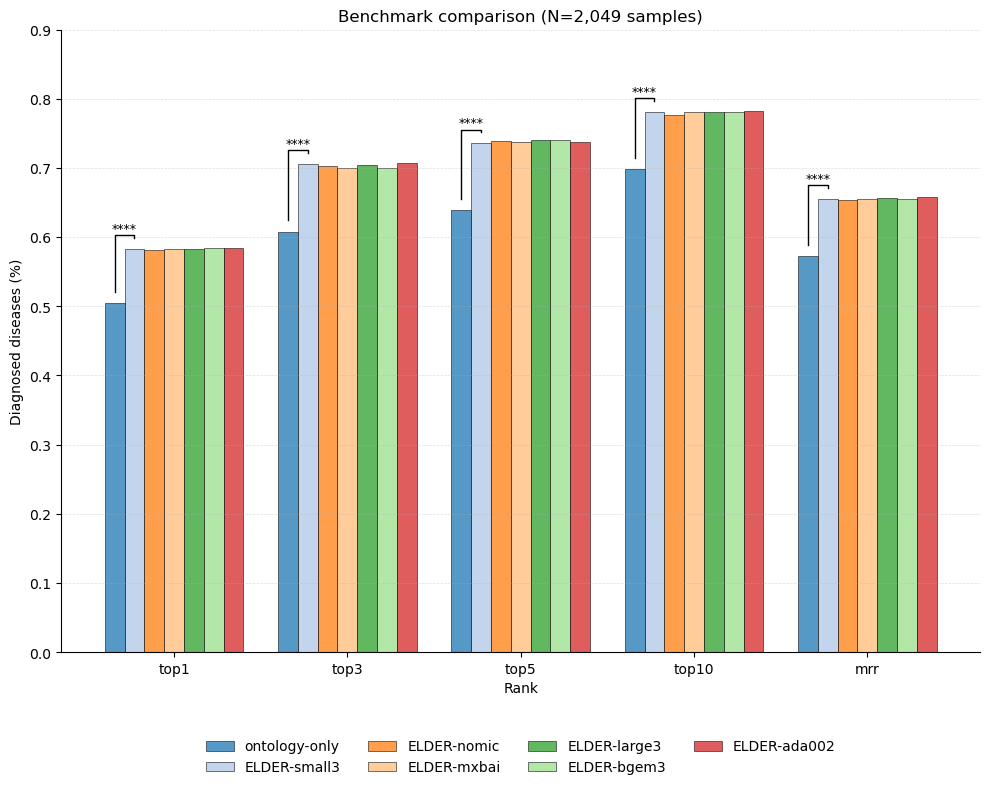

In [342]:
metrics = ["top1", "top3", "top5", "top10"]

# normalize counts
df2 = {}
df2 = data.copy()

## relabel runs ONLY for display (default data is named properly now from the beginning)
##df2["run"] = df2["run"].map(run_label_map).fillna(df2["run"])

for m in metrics:
    df2[m] = 100.0 * df2[m] / df2["total"]

# normalize MRR to %
df2["mrr"] = 100.0 * df2["mrr"]

# transpose trick
df_plot = df2.set_index("run")[metrics + ["mrr"]].T

n_runs = len(set(list(df2["run"])))
colors = get_nice_colormap(n_runs)


print("- {} colors/runs found".format(len(colors)))

fig, ax = plt.subplots(figsize=(10, 8))
ax = df_plot.plot(kind="bar",  
                  color=colors,
                  alpha=0.75,
                  edgecolor="black",
                  linewidth=0.5,
                  width=.8,
                  ax=ax)

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.4, zorder=-1)
ax.xaxis.grid(False)


for spine in ["top", "right"]:
   ax.spines[spine].set_visible(False)



# Percentage annotations
# value labels
#for container in ax.containers:
#    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)#, fontweight="bold")

bars_a, bars_b = ax.containers[0], ax.containers[1]
add_pvalue_brackets(ax, bars_a, bars_b, pvals, total_samples=[], show_nonsig=False, percent_space=True, show_pvals=False)

ax.set_ylabel("Diagnosed diseases (%)")
ax.set_xlabel("Rank")
ax.set_title("Benchmark comparison (N={} samples)".format(format(df2["total"][0], ',')))

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.xticks(rotation=0)

# Keep consistent with plots downstream in terms of yaxis (0-1, rather than 0-100)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, _: f"{y/100:.1f}"))

#plt.ylim(0, 60)
plt.ylim(0, 90)
plt.tight_layout()
plt.savefig(save_figure)
plt.savefig(save_figure.replace(".pdf", ".png"))

plt.show()

## Phenotype counts stratification

In [355]:
res_filepath = "/work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv"
stats_filepath = "/work/users/a/o/ao33/ELDER/stats_analsysis.tsv"
fig_dir = "/work/users/a/o/ao33/ELDER/FIGURES_NEW"
downsample = 3
os.makedirs(fig_dir, exist_ok=True)

# Format output names/paths for All data
if not downsample:
    # All data
    save_stats_name = "figure4_phenotype_stratification_allsamples.tsv"
    save_fig_name = "figure4_phenotype_stratification_allsamples.pdf"

# Downsampled data
else:
    save_stats_name = "figure4_phenotype_stratification_downsample{}.tsv".format(downsample)
    save_fig_name = "figure4_phenotype_stratification_downsample{}.pdf".format(downsample)


# Note, this is passed in to plt savefigure at the end
save_figure = os.path.join(fig_dir, save_fig_name)
save_stats = os.path.join(fig_dir, save_stats_name)


# Read results tables into memory
res_df = pd.read_csv(res_filepath, sep='\t')
stats_df = pd.read_csv(stats_filepath, sep='\t')

print("- Results found {} for {}".format(format(len(res_df), ','), res_filepath))
if downsample != False:
    res_df = res_df[res_df["downsample{}".format(downsample)] == 1].reset_index(drop=True)
    print("- Downsampled results found {} for v{}".format(format(len(res_df), ','), downsample))


- Results found 5,084 for /work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv
- Downsampled results found 2,049 for v3


In [356]:
# Tally rank counts across each group
p_groups = ["1-10", "10-20", "20-30", "30+"]
p_group_data_elder = {k:Counter() for k in p_groups}
p_group_data_exomiser = {k:Counter() for k in p_groups}

for i in range(0, len(res_df["sample_name"])):
    pgroup = res_df["p_group"][i]

    if type(pgroup) == type(np.nan):
        continue
    
    elder_res = res_df["ELDER-small3"][i]
    exomiser_res = res_df["ontology-only"][i]
    p_group_data_elder[pgroup][elder_res] += 1
    p_group_data_exomiser[pgroup][exomiser_res] += 1


# We want top1 rank (0 means not found, 1 is the best, 2 second best etc...
p_avgs_elder = [round(p_group_data_elder[p][1]/sum(list(p_group_data_elder[p].values())), 2) for p in p_groups]
p_avgs_exomiser = [round(p_group_data_exomiser[p][1]/sum(list(p_group_data_exomiser[p].values())), 2) for p in p_groups]
print(p_avgs_elder)
print(p_avgs_exomiser)

[0.5, 0.79, 0.62, 0.62]
[0.47, 0.6, 0.42, 0.54]


In [357]:
# Add in wilcoxon pvalues
pvals = []
comp_names = set(list(stats_df["comparison_name"]))
for p in p_groups:

    key = str(('global', 'patient-phenotype:{}'.format(p)))
    if key not in comp_names:
        print("- Skipping {} as no pvalue available...".format(key))
        pval = 1.
    
    else:
        pval = stats_df.loc[stats_df["comparison_name"] == key, "wilcox_pvalue"].iloc[0]
    
    pvals.append(pval)

# Now we quantify percentages and plot data
plot_df = pd.DataFrame({"Phenotype Count Bins":p_groups,
                        "ontology-only": p_avgs_exomiser,
                        "ELDER":p_avgs_elder}).set_index("Phenotype Count Bins")

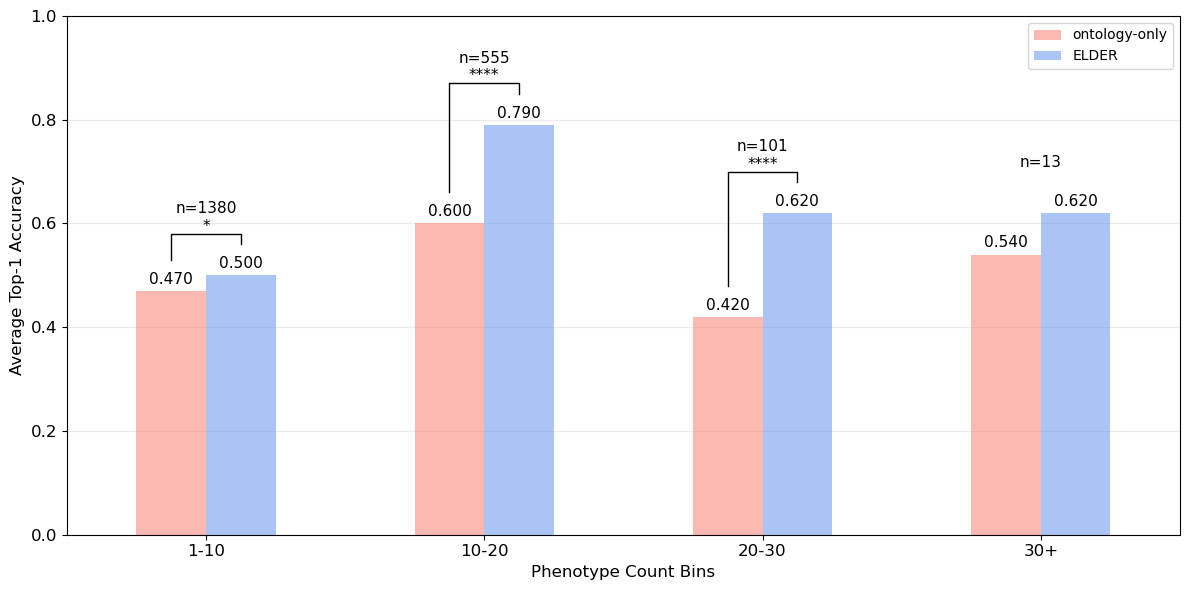

In [358]:
totals = [sum(p_group_data_elder[g].values()) for g in p_groups]

fs1 = 11
fs2 = 12
ax = plot_df.plot(kind="bar",
                  figsize=(12, 6),
                  rot=0,
                  alpha=0.55,
                  color=['salmon','cornflowerblue'])

ax.set_xlabel("Phenotype Count Bins", size=fs2)
#ax.set_xlabel("Phenotype Count Bins (phenotypes per case)")
ax.set_ylabel("Average Top-1 Accuracy", size=fs2)

#ax.set_ylim(0, .7)
ax.set_ylim(0, 1.)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(loc="upper right")

# Percentage annotations
# value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=fs1)#, fontweight="bold")
    

bars_a, bars_b = ax.containers[0], ax.containers[1]
add_pvalue_brackets(ax, bars_a, bars_b, pvals, total_samples=totals, show_nonsig=False, show_pvals=False, fs=fs1, pad=.05, h=.03)
ax.tick_params(axis='both', which='major', labelsize=fs2)

plt.tight_layout()
plt.savefig(save_figure)
plt.savefig(save_figure.replace(".pdf", ".png"))
plt.show()

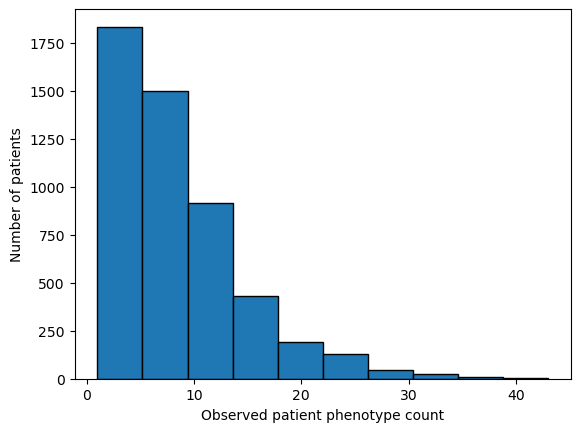

In [134]:
fig = plt.figure()
ax = plt.subplot2grid((1,1), (0,0))
ax.hist([p.phenotype_count for p in phenopacket_data.values()], edgecolor='black')
ax.set_xlabel("Observed patient phenotype count")
ax.set_ylabel("Number of patients")
plt.show()

In [ ]:
# sample_name: str
# phenopacket_path: str

# # Pulled from phenopacket
# phenotype_ids: list
# phenotype_count: int

# disease_name: str
# disease_id: str

# gene_symbol: str
# gene_id: str

# # For sssom mappings
# disease_mapped: Optional[str] = None
# gene_mapped: Optional[str] = None

## Disease phenotype counts stratification

In [378]:
res_filepath = "/work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv"
stats_filepath = "/work/users/a/o/ao33/ELDER/stats_analsysis.tsv"
fig_dir = "/work/users/a/o/ao33/ELDER/FIGURES_NEW"
downsample = False
os.makedirs(fig_dir, exist_ok=True)

# Format output names/paths for All data
if not downsample:
    # All data
    save_stats_name = "figure5_disease_stratification_allsamples.tsv"
    save_fig_name = "figure5_disease_stratification_allsamples.pdf"

# Downsampled data
else:
    save_stats_name = "figure5_disease_stratification_downsample{}.tsv".format(downsample)
    save_fig_name = "figure5_disease_stratification_downsample{}.pdf".format(downsample)

# Note, this is passed in to plt savefigure at the end
save_figure = os.path.join(fig_dir, save_fig_name)
save_stats = os.path.join(fig_dir, save_stats_name)

# Read results tables into memory
res_df = pd.read_csv(res_filepath, sep='\t')
stats_df = pd.read_csv(stats_filepath, sep='\t')

print("- Results found {} for {}".format(format(len(res_df), ','), res_filepath))
if downsample != False:
    res_df = res_df[res_df["downsample{}".format(downsample)] == 1].reset_index(drop=True)
    print("- Downsampled results found {} for v{}".format(format(len(res_df), ','), downsample))


- Results found 5,084 for /work/users/a/o/ao33/ELDER/compiled_analysis_data.tsv


In [372]:
# Tally rank counts across each group
d_groups = ["1-10", "10-20", "20-30", "30-40", "40+"]
d_group_data_elder = {k:Counter() for k in d_groups}
d_group_data_exomiser = {k:Counter() for k in d_groups}

for i in range(0, len(res_df["sample_name"])):
    
    dgroup = res_df["d_group"][i]

    if type(dgroup) == type(np.nan):
        continue
    
    elder_res = res_df["ELDER-small3"][i]
    exomiser_res = res_df["ontology-only"][i]
    d_group_data_elder[dgroup][elder_res] += 1
    d_group_data_exomiser[dgroup][exomiser_res] += 1


# We want top1 rank (0 means not found, 1 is the best, 2 second best etc...
d_avgs_elder = [round(d_group_data_elder[p][1]/sum(list(d_group_data_elder[p].values())), 2) for p in d_groups]
d_avgs_exomiser = [round(d_group_data_exomiser[p][1]/sum(list(d_group_data_exomiser[p].values())), 2) for p in d_groups]
print(d_avgs_elder)
print(d_avgs_exomiser)

[0.43, 0.43, 0.58, 0.69, 0.63]
[0.43, 0.41, 0.51, 0.61, 0.52]


In [373]:
# Add in wilcoxon pvalues
pvals = []
comp_names = set(list(stats_df["comparison_name"]))
for d in d_groups:

    key = str(('global', 'disease-phenotype:{}'.format(d)))
    if key not in comp_names:
        print("- Skipping {} as no pvalue available...".format(key))
        pval = 1.
    
    else:
        pval = stats_df.loc[stats_df["comparison_name"] == key, "wilcox_pvalue"].iloc[0]
    
    pvals.append(pval)


# Now we quantify percentages and plot data
plot_df = pd.DataFrame({"Phenotype Count Bins":d_groups,
                        "ontology-only": d_avgs_exomiser,
                        "ELDER":d_avgs_elder}).set_index("Phenotype Count Bins")

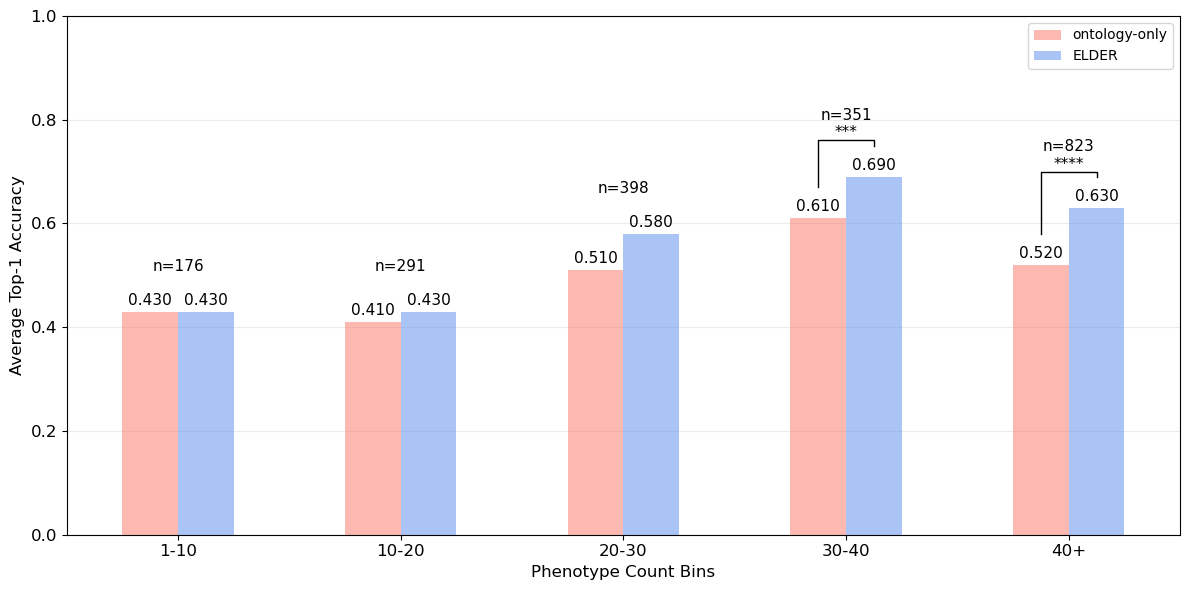

In [374]:
d_groups = ["1-10", "10-20", "20-30", "30-40", "40+"]
totals = [sum(d_group_data_elder[g].values()) for g in d_groups]

fs1 = 11
fs2 = 12
ax = plot_df.plot(kind="bar",
                  figsize=(12, 6),
                  rot=0,
                  alpha=0.55,
                  color=['salmon','cornflowerblue'])

ax.set_xlabel("Phenotype Count Bins", size=fs2)
#ax.set_xlabel("Phenotype Count Bins (phenotypes per case)")
ax.set_ylabel("Average Top-1 Accuracy", size=fs2)

#ax.set_ylim(0, .7)
ax.set_ylim(0, 1.)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.legend(loc="upper right")

# Percentage annotations
# value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=fs1)#, fontweight="bold")
    

bars_a, bars_b = ax.containers[0], ax.containers[1]
add_pvalue_brackets(ax, bars_a, bars_b, pvals, total_samples=totals, show_nonsig=False, show_pvals=False, fs=fs1, pad=.04, h=.03)
ax.tick_params(axis='both', which='major', labelsize=fs2)

plt.tight_layout()
plt.savefig(save_figure)
plt.savefig(save_figure.replace(".pdf", ".png"))
plt.show()

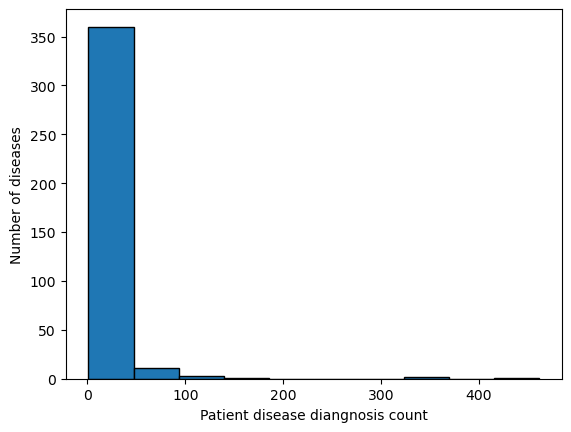

In [381]:
disease_pid_counts = Counter([p for p in res_df["disease_id"]])

fig = plt.figure()
ax = plt.subplot2grid((1,1), (0,0))
ax.hist(list(disease_pid_counts.values()), edgecolor='black')
ax.set_xlabel("Patient disease diangnosis count")
ax.set_ylabel("Number of diseases")
plt.show()

In [383]:
# Display disease names with most to least patient diagnosis in our dataset (top20)
for kk,vv in sorted([[k,v] for k,v in disease_pid_counts.items()], key=lambda x: x[1], reverse=True):#[0:20]:
    print(kk,vv)

OMIM:612164 462
OMIM:613721 342
OMIM:148050 333
OMIM:612313 157
OMIM:613826 113
OMIM:142900 99
OMIM:615471 95
OMIM:618505 73
OMIM:147791 69
OMIM:147920 62
OMIM:618362 60
OMIM:616362 60
OMIM:617140 52
OMIM:607745 51
OMIM:154700 50
OMIM:256810 50
OMIM:175700 50
OMIM:620535 49
OMIM:613795 47
OMIM:248250 46
OMIM:615502 46
OMIM:618164 45
OMIM:129600 44
OMIM:115200 43
OMIM:616211 43
OMIM:181350 41
OMIM:615582 41
OMIM:130050 35
OMIM:614816 34
OMIM:272300 34
OMIM:606693 33
OMIM:617560 33
OMIM:151100 31
OMIM:604377 30
OMIM:606574 30
OMIM:301111 29
OMIM:605911 29
OMIM:620731 28
OMIM:620538 28
OMIM:163950 27
OMIM:154400 25
OMIM:268310 25
OMIM:620465 24
OMIM:616900 23
OMIM:620681 22
OMIM:613477 22
OMIM:620537 22
OMIM:610168 21
OMIM:146510 21
OMIM:159550 20
OMIM:620540 20
OMIM:605275 20
OMIM:618089 20
OMIM:618443 20
OMIM:619375 20
OMIM:614185 19
OMIM:616975 19
OMIM:601674 19
OMIM:301310 18
OMIM:132800 18
OMIM:620568 18
OMIM:616462 18
OMIM:179800 18
OMIM:240300 17
OMIM:616914 17
OMIM:242840 17
OMIM:

In [146]:
print(len(hpo_map['MONDO:0012812']))
print(len(hpo_map['MONDO:0013388']))
print(len(hpo_map['MONDO:0007846']))

31
14
40


In [ ]:
    # Loop through all phenopackets, extract / map data and return Patient objects
    for sname, spath in sample_path_dict.items():
        
        phenopacket_util = PhenopacketUtil(phenopacket_reader(Path(spath)))
        observed_phenotypes = phenopacket_util.observed_phenotypic_features()
        phenotype_ids = [observed_phenotype.type.id for observed_phenotype in observed_phenotypes]
        phenotype_count = len(phenotype_ids)
        
        # Default is to take first term 
        # Will display how many multi terms there are at end... should be few if not none)
        dis_obj = phenopacket_util.diseases()[0]
        dis_name, dis_id = dis_obj.term.label, dis_obj.term.id
        
        gene_obj = phenopacket_util.diagnosed_genes()[0]
        gene_symbol, gene_id = gene_obj.gene_symbol, gene_obj.gene_identifier

In [ ]:
    for i,phpath in enumerate(paths):
        phenopacket_util = PhenopacketUtil(phenopacket_reader(phpath)) # Requires Path object
        observed_phenotypes = phenopacket_util.observed_phenotypic_features()
        phenotype_ids = [observed_phenotype.type.id for observed_phenotype in observed_phenotypes]
        phenotype_count = len(phenotype_ids)
        if phenotype_count <= 0:
            phpath.unlink()
            removed_samples += 1

In [ ]:
import sqlite3

dbfile = "/work/users/a/o/ao33/EXOMISER_RELEASES/exomiser-cli-14.1.0_phenio100_fish/data/phenio100_phenotype"
conn = sqlite3.connect(dbfile)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(tables)

In [ ]:
dbfile = "/work/users/a/o/ao33/EXOMISER_RELEASES/exomiser-cli-14.1.0_phenio100_fish/data/phenio100_phenotype"